# Проведение EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from wcwidth import width

## Датасет и первичное EDA

In [2]:
data = pd.read_excel('data/Mars 2 Data Chanels.xlsx')

In [3]:
data.describe()

,PER_SDESC,MT_Volume KG,NT_CWD,NT_Avg Line,NT_Price per kg,NT_Universe,MT_Universe percent,Frequency,Penetration,Spend per Trip,Volume per Trip,Total Mixed Chains - VoD (Vol)
count,2860,2.860000e+03,2860.000000,2860.000000,2860.000000,2860.000000,2860.000000,2860.000000,2860.000000,2860.000000,2860.000000,1560.000000
mean,2021-08-31 08:51:41.538461,1.599484e+06,4426.122206,44.850424,1212.245375,26091.848963,0.139215,1.918336,10.499896,118.868070,0.195458,2.667303
min,2019-01-01 00:00:00,7.280700e+03,145.430000,1.998571,269.904442,691.000066,0.003610,1.089104,0.225923,34.238049,0.019910,1.139539
25%,2020-05-01 00:00:00,1.211586e+05,868.717500,9.088388,559.217402,16363.454807,0.081640,1.440835,2.835675,69.400742,0.050145,1.760203
50%,2021-09-01 00:00:00,5.379566e+05,3104.835000,32.561282,808.480041,29576.880495,0.158075,1.736031,7.179139,104.631607,0.152070,2.255146
75%,2023-01-01 00:00:00,2.098726e+06,5296.690000,53.750051,1578.968292,36407.629805,0.197806,2.228256,12.657769,147.350418,0.282667,3.007301
max,2024-05-01 00:00:00,1.367844e+07,31155.010000,311.550100,4717.061844,59799.608120,0.331741,4.169881,62.335266,463.456390,0.891444,17.478635
std,NaN,2.306368e+06,5067.127235,50.581166,939.570461,16315.208107,0.088647,0.642712,11.522542,68.123965,0.168028,1.558980


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2860 entries, 0 to 2859
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Row Labels                      2860 non-null   str           
 1   MKT_SDESC                       2860 non-null   str           
 2   PER_SDESC                       2860 non-null   datetime64[us]
 3   MT_Volume KG                    2860 non-null   float64       
 4   NT_CWD                          2860 non-null   float64       
 5   NT_Avg Line                     2860 non-null   float64       
 6   NT_Price per kg                 2860 non-null   float64       
 7   NT_Universe                     2860 non-null   float64       
 8   MT_Universe percent             2860 non-null   float64       
 9   Frequency                       2860 non-null   float64       
 10  Penetration                     2860 non-null   float64       
 11  Spend per Trip 

In [5]:
data.head()

,Row Labels,MKT_SDESC,PER_SDESC,MT_Volume KG,NT_CWD,NT_Avg Line,NT_Price per kg,NT_Universe,MT_Universe percent,Frequency,Penetration,Spend per Trip,Volume per Trip,Total Mixed Chains - VoD (Vol)
0,BAGS,Discounters,2019-01-01,1458414.5,3175.94,31.759400,361.647156,26047.36129,0.126383,1.779020,7.630785,137.827270,0.745170,NaN
1,BAGS,Discounters,2019-02-01,1599316.0,3151.74,31.517400,357.873791,26385.74648,0.127194,1.779020,7.630785,137.827270,0.745170,NaN
2,BAGS,Discounters,2019-03-01,1505515.5,3155.40,31.554000,385.256139,26475.00379,0.128160,1.779020,7.630785,137.827270,0.745170,NaN
3,BAGS,Discounters,2019-04-01,1565605.8,3414.86,34.152015,393.144379,26895.73306,0.129438,1.792873,9.147782,149.472214,0.850036,NaN
4,BAGS,Discounters,2019-05-01,1508979.0,3394.44,33.944400,404.401652,27153.48617,0.130361,1.792873,9.147782,149.472214,0.850036,NaN


**Описание колонок данных**

| Column Name | Data Type | Group | Description | Mean Value | Business Meaning | Notes |
|-------------|-----------|-------|-------------|------------|------------------|-------|
| **Row Labels** | `str` | Идентификаторы | Метка строки в отчете. Детализация внутри категории | - | Конкретный продукт/SKU | Например: "Mars Milk Chocolate 100g" |
| **MKT_SDESC** | `str` | Идентификаторы | Market Short Description - категория товара | - | Группа товаров | Например: "Шоколадные батончики", "Корма" |
| **PER_SDESC** | `datetime64` | Идентификаторы | Period Short Description - дата/период | 2021-08-31 | Временной срез | Уже преобразовано в datetime |
| **MT_Volume KG** | `float64` | Базовые метрики | Market Volume - объем продаж в кг | 1,599,484 | Сколько товара продано | Мин: 7,280, Макс: 13.7 млн |
| **NT_CWD** | `float64` | Базовые метрики | National Turnover - выручка | 4,426 | Деньги | Мин: 145, Макс: 31,155 |
| **NT_Avg Line** | `float64` | Ценовые метрики | Средний чек / стоимость позиции | 44.85 | Цена одной покупки | - |
| **NT_Price per kg** | `float64` | Ценовые метрики | Цена за килограмм | 1,212 | Цена продукта | Мин: 270, Макс: 4,717 |
| **NT_Universe** | `float64` | Аудитория | Размер вселенной покупателей | 26,092 | Потенциальная аудитория | База для расчетов |
| **MT_Universe percent** | `float64` | Аудитория | Доля от вселенной | 0.1392 (13.9%) | Доля рынка | - |
| **Frequency** | `float64` | Поведенческие | Частота покупок | 1.92 | Лояльность | Мин: 1.09, Макс: 4.17 |
| **Penetration** | `float64` | Поведенческие | Проникновение (% купивших) | 10.5% | Охват | Мин: 0.23%, Макс: 62.3% |
| **Spend per Trip** | `float64` | Поведенческие | Трат за поход в магазин | 118.87 | Глубина корзины (денежная) | - |
| **Volume per Trip** | `float64` | Поведенческие | Объем за поход в магазин | 0.196 кг | Глубина корзины (физическая) | - |
| **Total Mixed Chains - VoD (Vol)** | `float64` | Спец. метрика | Объем в смешанных сетях | 2.67 | Специфический канал | 54% данных заполнено (1560 из 2860) |

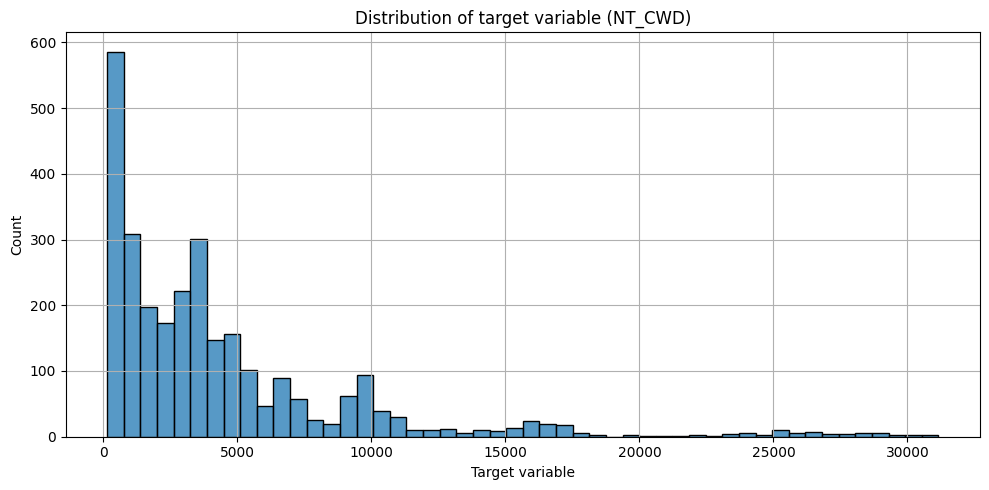

In [243]:
plt.figure(figsize=(10,5))
sns.histplot(data["NT_CWD"], bins=50)
plt.xlabel('Target variable')
title = "Distribution of target variable (NT_CWD)"
plt.title(title)
plt.grid()
plt.tight_layout()
plt.savefig('plots/'+title+'.png')
plt.show()

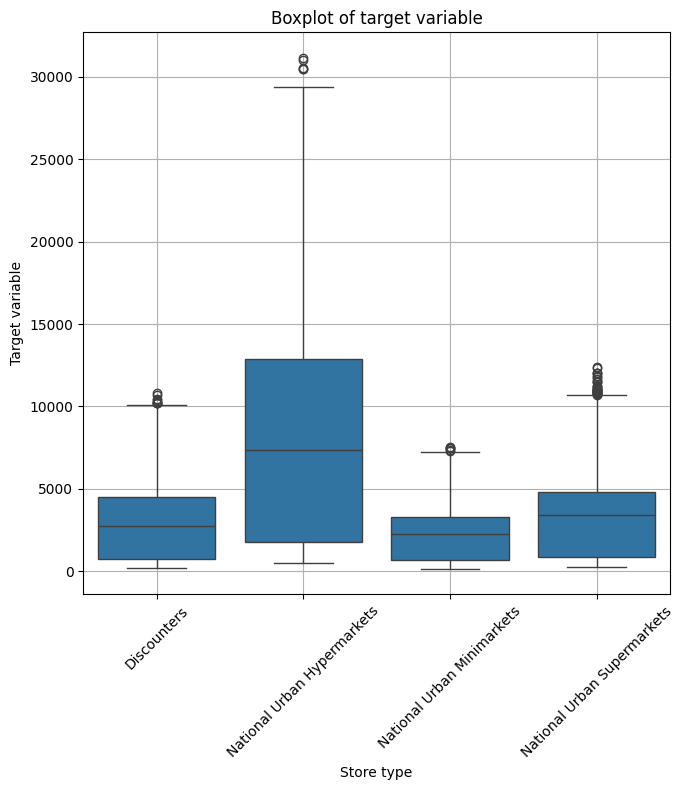

In [250]:
plt.figure(figsize=(7,8))
sns.boxplot(x="MKT_SDESC", y="NT_CWD", data=data)
plt.xticks(rotation=45)
plt.xlabel('Store type')
plt.ylabel('Target variable')
title = 'Boxplot of target variable'
plt.title(title)
plt.grid()
plt.tight_layout()
plt.savefig('plots/'+title+'.png')
plt.show()

### Create new data columns

In [123]:
data['year'] = data['PER_SDESC'].dt.year
data['month'] = data['PER_SDESC'].dt.month
data['quarter'] = data['PER_SDESC'].dt.quarter
data['year_month'] = data['PER_SDESC'].dt.to_period('M')
data = data.sort_values(
    ["Row Labels","MKT_SDESC","PER_SDESC"]
)
for lag in [1,3,6,12]:
    data[f"sales_lag{lag}"] = data.groupby(
        ["Row Labels","MKT_SDESC"]
    )["NT_CWD"].shift(lag)



In [147]:
for rol in [1,3,6,12]:
    data[f'sales_rolling{rol}_mean'] = data['NT_CWD'].rolling(rol).mean()
    data[f'sales_rolling{rol}_std'] = data['NT_CWD'].rolling(rol).std()

### Outliers check

In [254]:
group_cols = ['Row Labels', 'MKT_SDESC']

q1 = data.groupby(group_cols)['NT_CWD'].transform(lambda x: x.quantile(0.25))
q3 = data.groupby(group_cols)['NT_CWD'].transform(lambda x: x.quantile(0.75))

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = data[(data['NT_CWD'] < lower) | (data['NT_CWD'] > upper)]

print("Outliers:", len(outliers))
print(f'Percent of outliers: {len(outliers)*100 / len(data)}%')

Outliers: 26
Percent of outliers: 0.9090909090909091%


In [255]:
# избавление от выбросов
data["NT_CWD_clean"] = data["NT_CWD"].clip(lower=lower, upper=upper)

## Main Analysis

### Plots

In [259]:
def plot_ts(df, x, y, title, hue):
    plt.figure(figsize=(15,5))
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Revenue')
    sns.lineplot(df, x = x, y=y, hue = hue)
    if hue is not None:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
        # Автоматически подгоняем размер, чтобы легенда не обрезалась
    plt.tight_layout()
    plt.grid()
    plt.savefig('plots/'+title+'.png')
    plt.show()

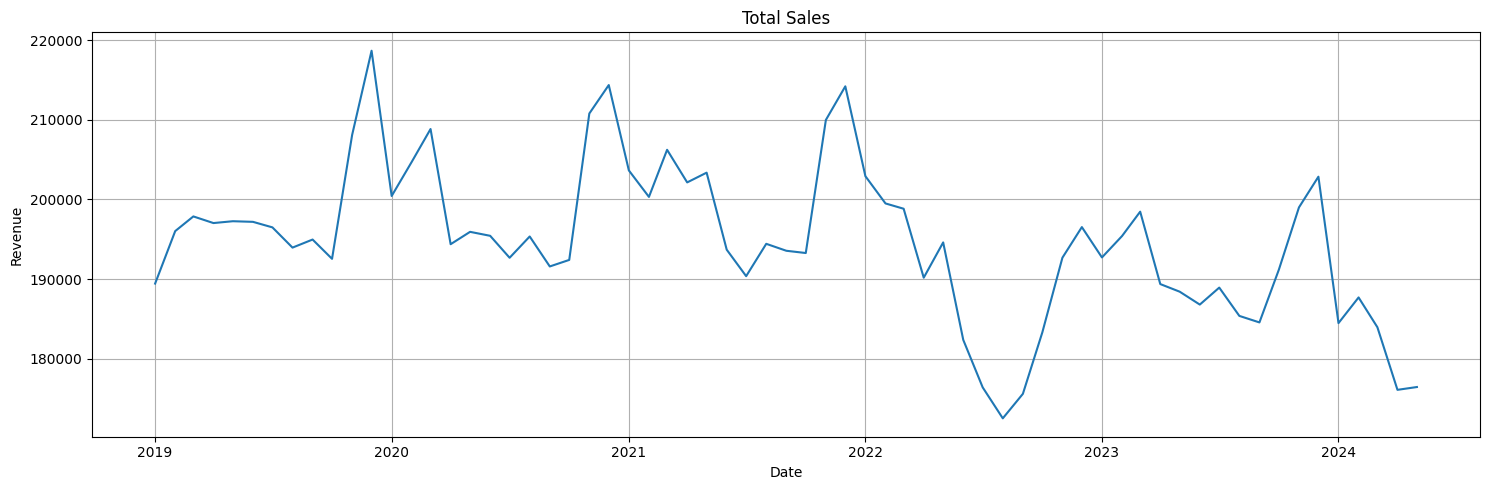

In [169]:
# Total
total_sales = data.groupby('PER_SDESC').agg({'NT_CWD':'sum'}).reset_index()
plot_ts(total_sales,x= 'PER_SDESC', y='NT_CWD', title='Total Sales', hue=None)

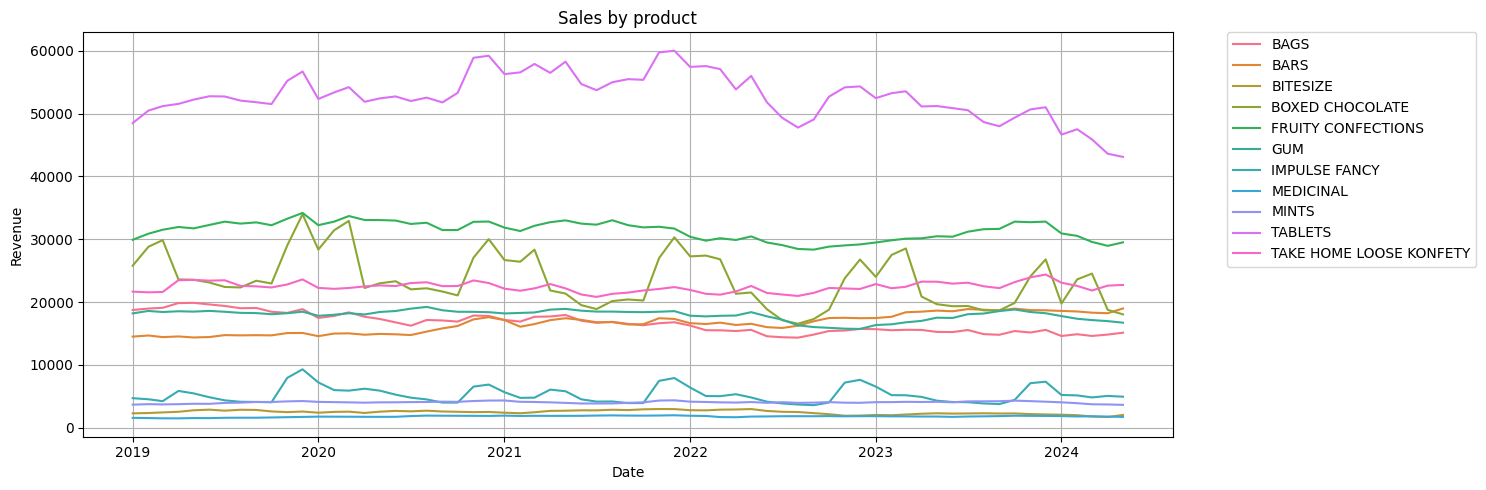

In [170]:
goods = data.groupby(['PER_SDESC', 'Row Labels']).agg({'NT_CWD':'sum'}).reset_index()
plot_ts(goods,x= 'PER_SDESC', y='NT_CWD', title='Sales by product', hue='Row Labels')

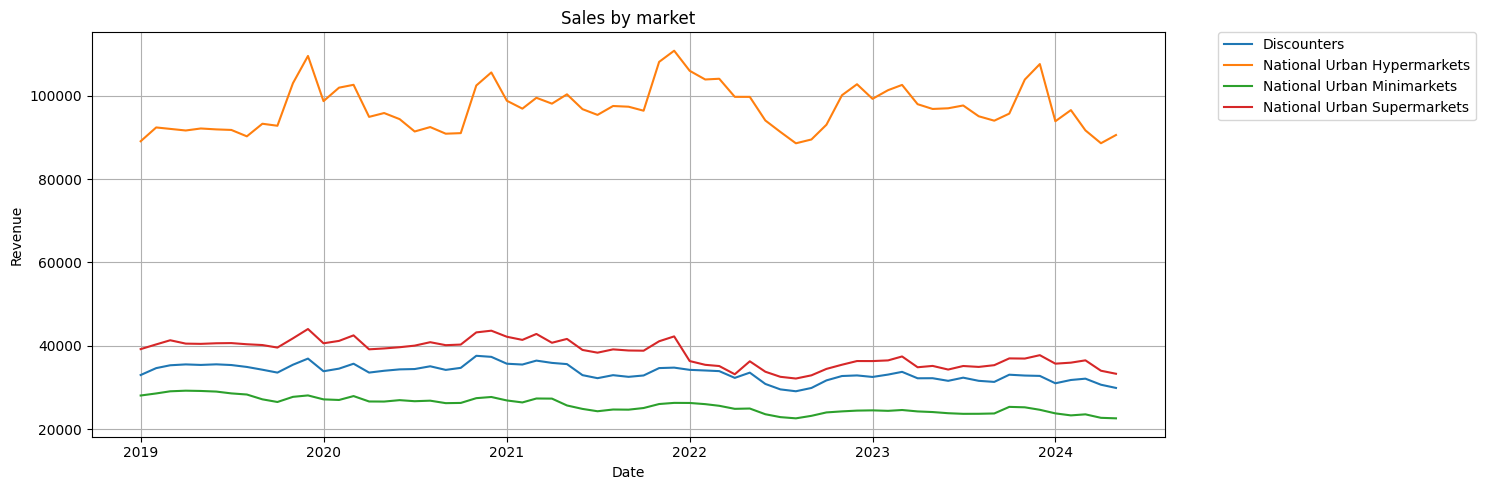

In [171]:
stores = data.groupby(['PER_SDESC', 'MKT_SDESC']).agg({ 'NT_CWD':'sum'}).reset_index()
plot_ts(stores,x= 'PER_SDESC', y='NT_CWD', title='Sales by market', hue='MKT_SDESC')

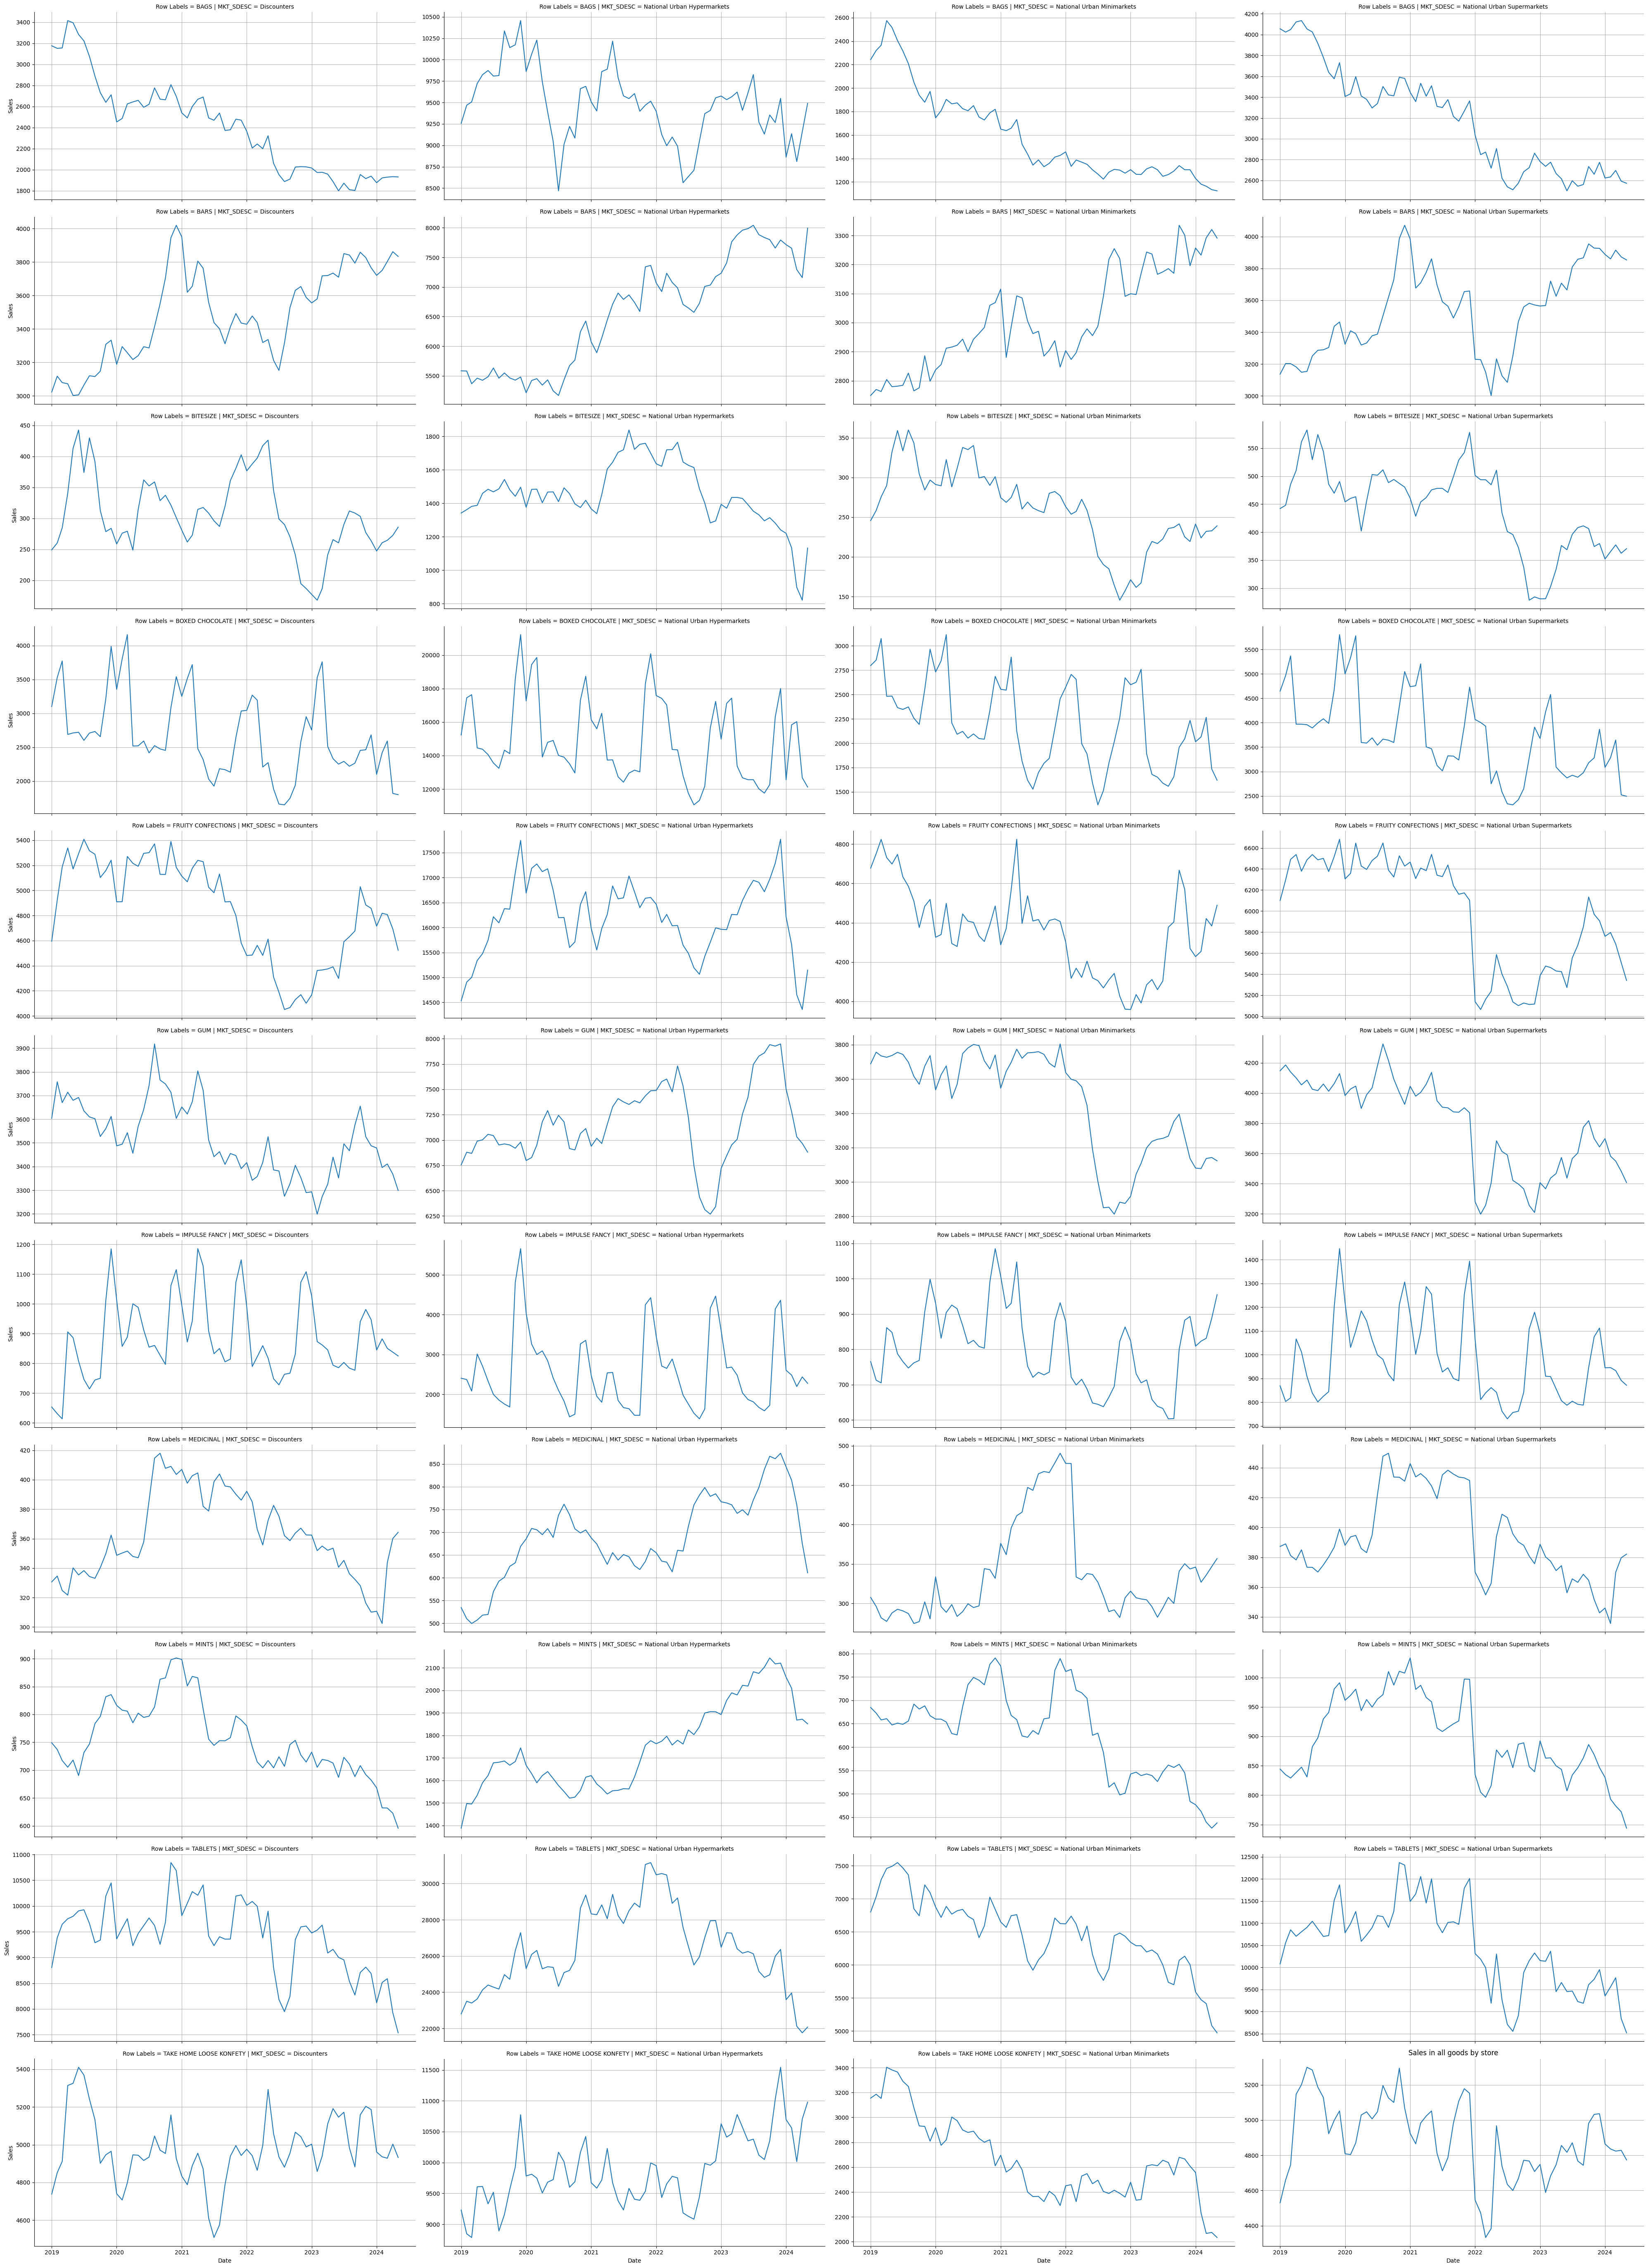

In [200]:
df = (
    data
    .groupby(['Row Labels', 'MKT_SDESC', 'PER_SDESC'])
    .agg({'NT_CWD':'sum'})
    .reset_index()
)

df['PER_SDESC'] = pd.to_datetime(df['PER_SDESC'])

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df,
    row='Row Labels',        # товары
    col='MKT_SDESC',         # тип магазина
    height=5,
    aspect=2,
    sharey=False,
    sharex=True
)

g.map_dataframe(
    sns.lineplot,
    x='PER_SDESC',
    y='NT_CWD'
)
for ax in g.axes.flat:
    ax.grid(True)
g.set_axis_labels("Date", "Sales")
plt.title('Sales in all goods by store')
plt.tight_layout()
plt.savefig('plots/all_goods.png')
plt.show()

По графикам выше наблюдаются можно наблюдать:
1) При разделении по типу магазина наблюдаются две основные категории поведения временных рядов: национальные городские гипермаркеты генерируют основную выручку компании, в них ярковыраженная сезонность и нет тренда, остальные типы магазинов показывают одинаковый паттерн поведения: ярко-выраженный тренд, низкая сезонность
2) Хоть среди магазинов всего два паттерна динамики цены, внутри каждого отдельного товара в группе магазина паттерны динамики отличаются, поэтому лучше строить прогнозы для разреза продукт+магазин отдельно, после чего аггрегировать и получать суммарную выручку компании

### Functions

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def basic_ts_analysis(df, date_col, target_col):

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    print("Размер данных:", df.shape)
    print("Пропуски:", df[target_col].isna().sum())

    fig, axes = plt.subplots(2,2, figsize=(14,8))

    # временной ряд
    axes[0,0].plot(df[date_col], df[target_col])
    axes[0,0].set_title("Time Series")

    # распределение
    sns.histplot(df[target_col], bins=30, ax=axes[0,1])
    axes[0,1].set_title("Distribution")

    # boxplot
    sns.boxplot(y=df[target_col], ax=axes[1,0])
    axes[1,0].set_title("Boxplot")

    # rolling mean
    rolling = df[target_col].rolling(7).mean()
    axes[1,1].plot(df[date_col], df[target_col])
    axes[1,1].plot(df[date_col], rolling)
    axes[1,1].set_title("Rolling Mean")

    plt.tight_layout()
    plt.show()

def decompose_series(series, period=12):

    stl = STL(series, period=period)
    result = stl.fit()

    result.plot()
    plt.show()

    return result

def check_stationarity(series):

    result = adfuller(series.dropna())

    print("ADF statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Ряд стационарный")
    else:
        print("Ряд нестационарный")

def plot_autocorrelation(series):
    n = len(series)
    max_lags = int(n/2) - 1

    fig, axes = plt.subplots(1,2, figsize=(12,4))

    plot_acf(series, lags=max_lags, ax=axes[0])
    plot_pacf(series, lags=max_lags, ax=axes[1])

    axes[0].set_title("ACF")
    axes[1].set_title("PACF")

    plt.show()

def create_lag_features(df, target_col, lags=[1,7,14]):

    df = df.copy()

    for lag in lags:
        df[f'lag_{lag}'] = df[target_col].shift(lag)

    return df

def create_rolling_features(df, target_col):

    df['rolling_mean_7'] = df[target_col].rolling(7).mean()
    df['rolling_std_7'] = df[target_col].rolling(7).std()

    return df

def analyze_series(df, date_col, target_col, title, period):

    df = df.sort_values(date_col)

    series = df.set_index(date_col)[target_col]

    print(f"\n===== {title} =====")
    print("Observations:", len(series))

    # график
    plt.figure(figsize=(10,4))
    plt.plot(series)
    plt.title(title)
    plt.show()

    # декомпозиция
    try:
        decompose_series(series, period = period)
    except:
        print("STL decomposition failed")

    # стационарность
    try:
        check_stationarity(series)
    except:
        print("ADF test failed")

    # автокорреляция
    try:
        plot_autocorrelation(series)
    except:
        print("ACF/PACF failed")

def ts_diagnostics(series, period=12):

    result = {}

    series = series.dropna()

    # базовые статистики
    result["mean"] = series.mean()
    result["std"] = series.std()
    result["cv"] = series.std() / series.mean()

    # ADF
    adf = adfuller(series)
    result["adf_pvalue"] = adf[1]

    # STL
    try:
        stl = STL(series, period=period).fit()

        trend_var = np.var(stl.trend)
        resid_var = np.var(stl.resid)
        season_var = np.var(stl.seasonal)

        result["trend_strength"] = trend_var / (trend_var + resid_var)
        result["season_strength"] = season_var / (season_var + resid_var)

    except:
        result["trend_strength"] = np.nan
        result["season_strength"] = np.nan

    # ACF / PACF
    try:
        acf_vals = acf(series, nlags=max(5, period))
        pacf_vals = pacf(series, nlags=5)

        result["acf_lag1"] = acf_vals[1]
        result["acf_season"] = acf_vals[period] if len(acf_vals) > period else np.nan
        result["pacf_lag1"] = pacf_vals[1]
        result["acf_sum5"] = np.sum(np.abs(acf_vals[1:6]))

    except:
        result["acf_lag1"] = np.nan
        result["acf_season"] = np.nan
        result["pacf_lag1"] = np.nan
        result["acf_sum5"] = np.nan

    return result

### TS analyze

In [173]:
ts = data.groupby(['PER_SDESC', 'MKT_SDESC', 'Row Labels']).agg({'NT_CWD':'sum'}).reset_index()


===== BAGS — Discounters =====
Observations: 65


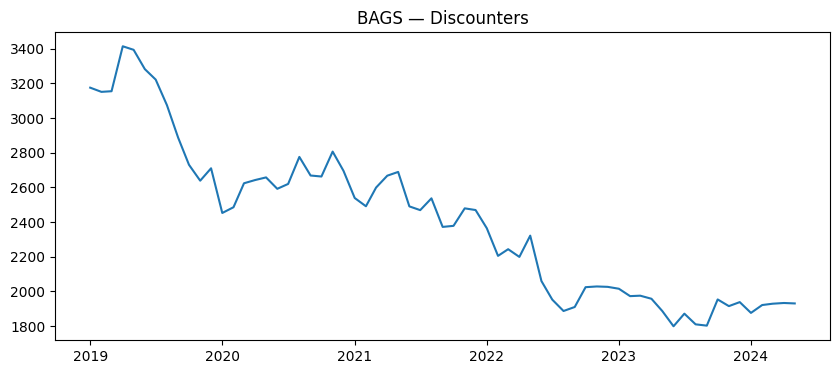

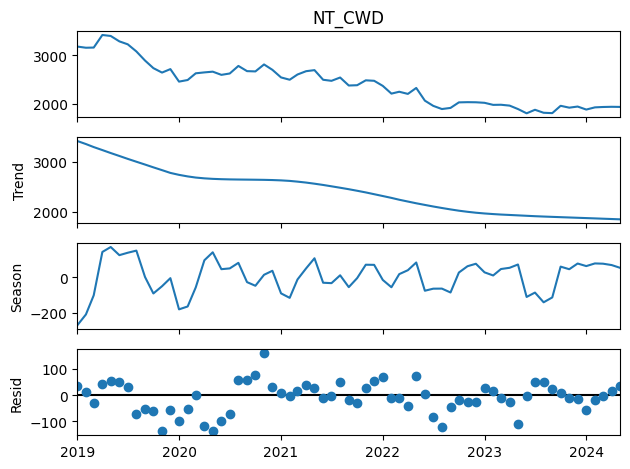

ADF statistic: -1.4346611071498596
p-value: 0.5655510267408934
Ряд нестационарный


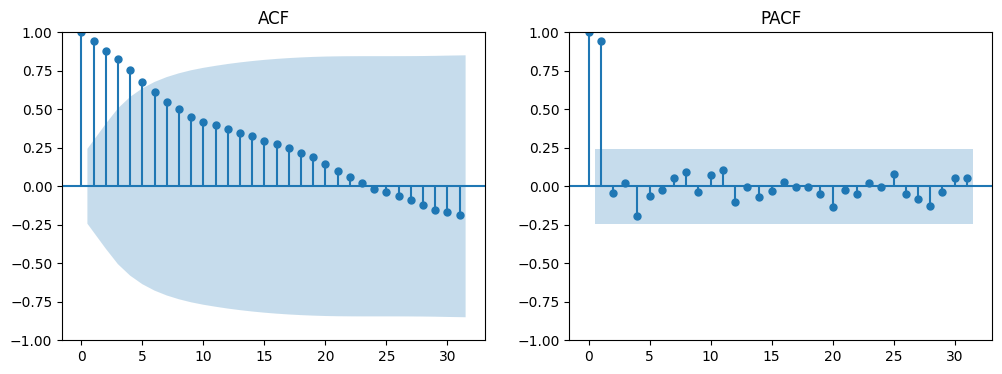


===== BAGS — National Urban Hypermarkets =====
Observations: 65


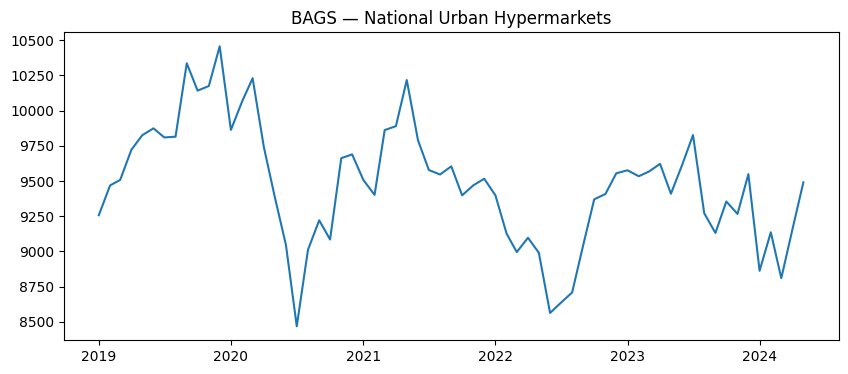

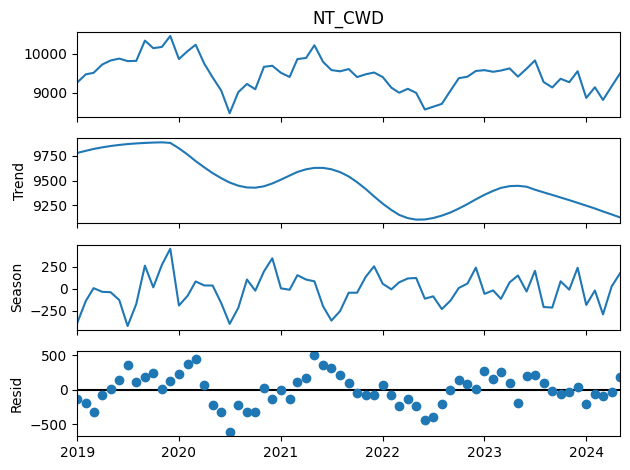

ADF statistic: -2.7961844827829547
p-value: 0.058820857890500934
Ряд нестационарный


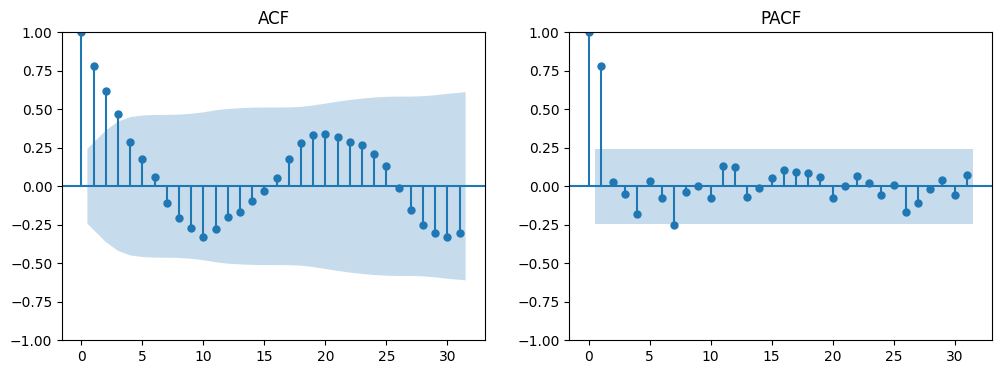


===== BAGS — National Urban Minimarkets =====
Observations: 65


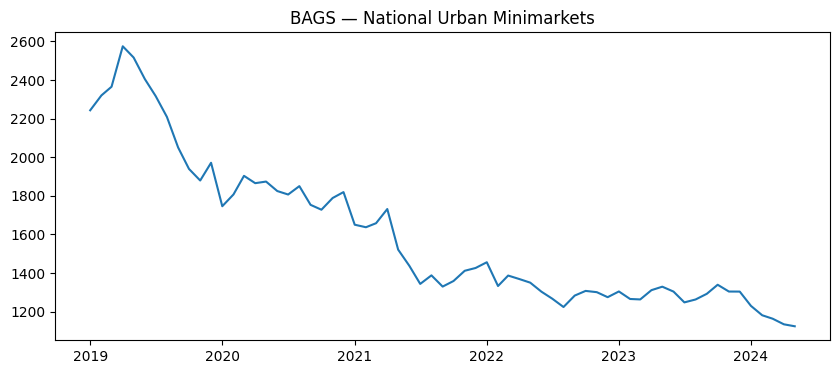

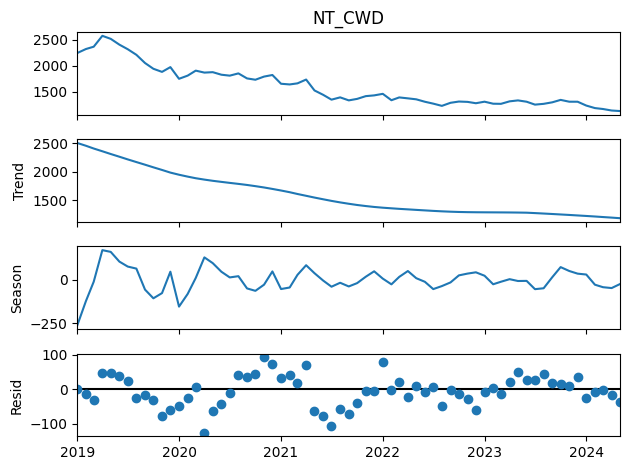

ADF statistic: -1.2323200348406618
p-value: 0.6595402621868467
Ряд нестационарный


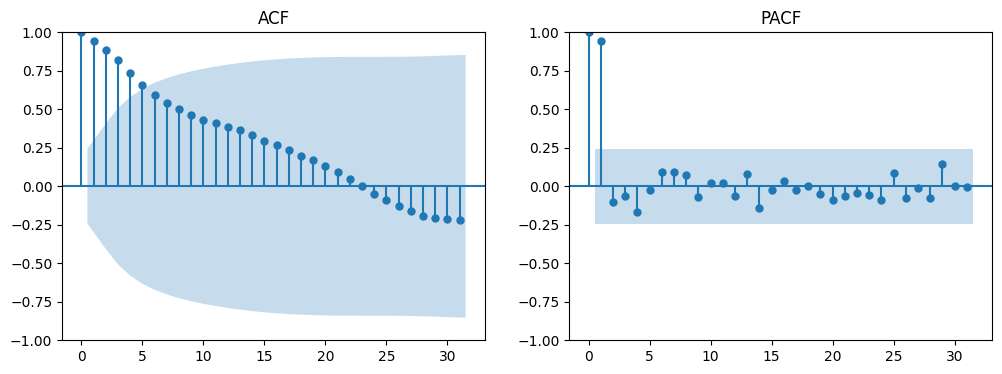


===== BAGS — National Urban Supermarkets =====
Observations: 65


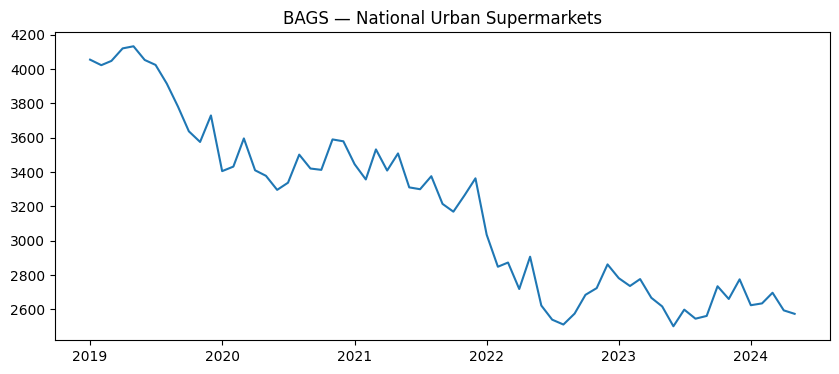

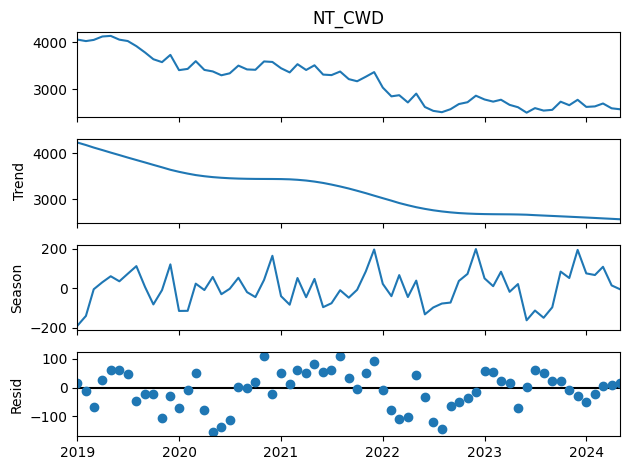

ADF statistic: -1.303931568587517
p-value: 0.6273717021897038
Ряд нестационарный


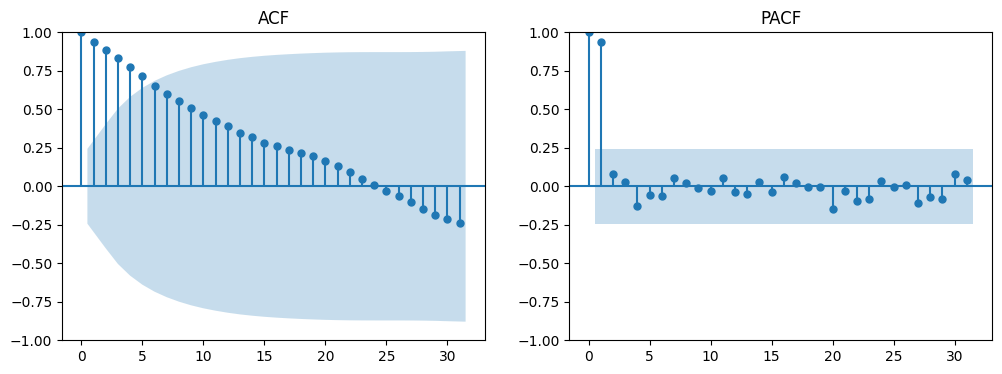


===== BARS — Discounters =====
Observations: 65


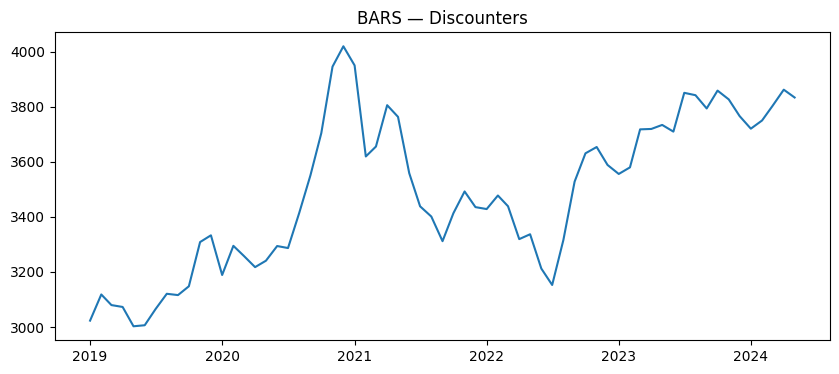

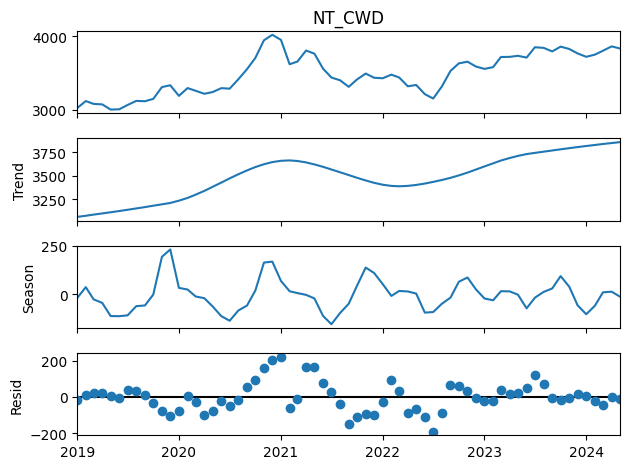

ADF statistic: -1.7550253558587903
p-value: 0.403007688888513
Ряд нестационарный


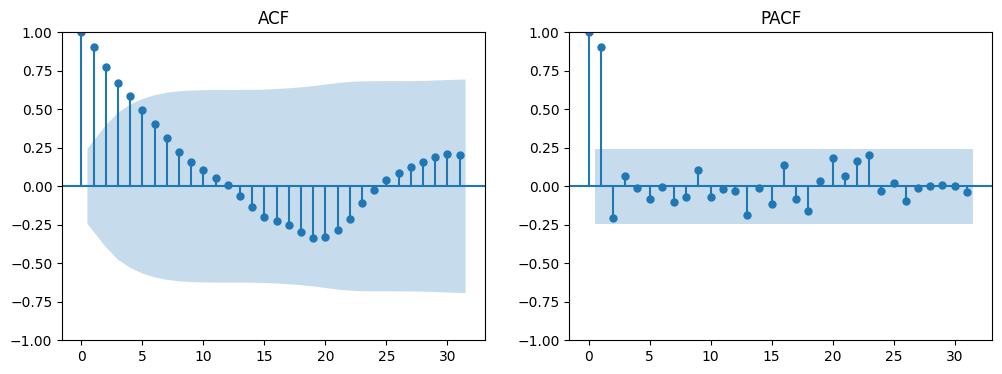


===== BARS — National Urban Hypermarkets =====
Observations: 65


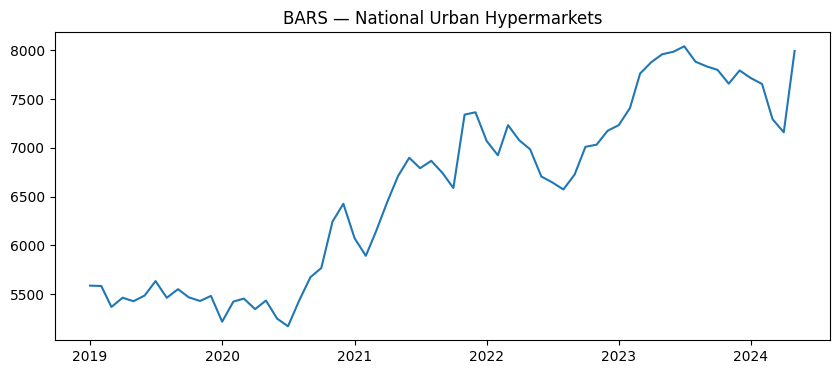

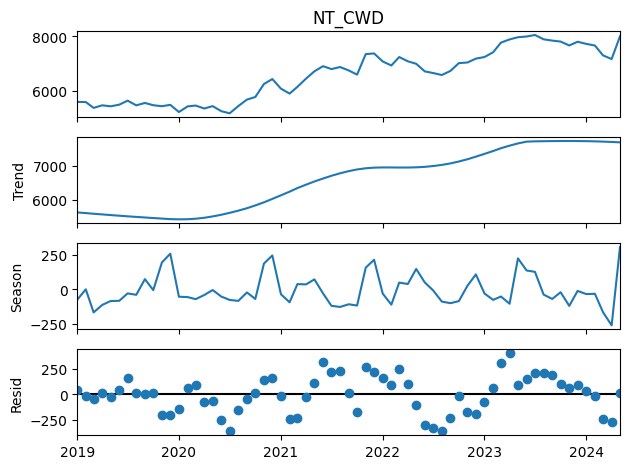

ADF statistic: -0.6552695461108394
p-value: 0.8579981266345413
Ряд нестационарный


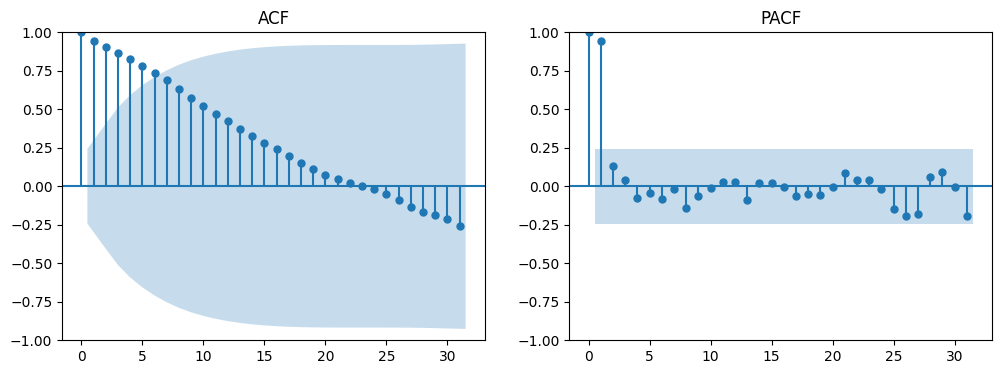


===== BARS — National Urban Minimarkets =====
Observations: 65


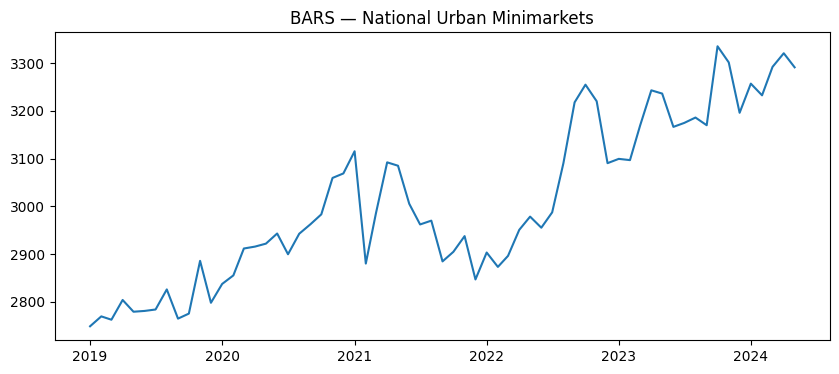

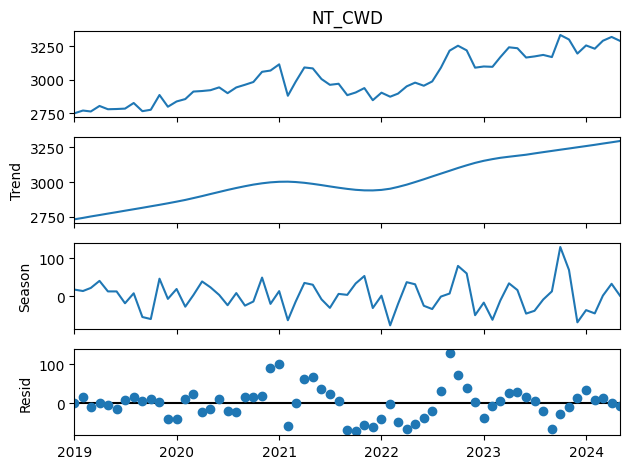

ADF statistic: -1.4824437135549478
p-value: 0.5421776181351909
Ряд нестационарный


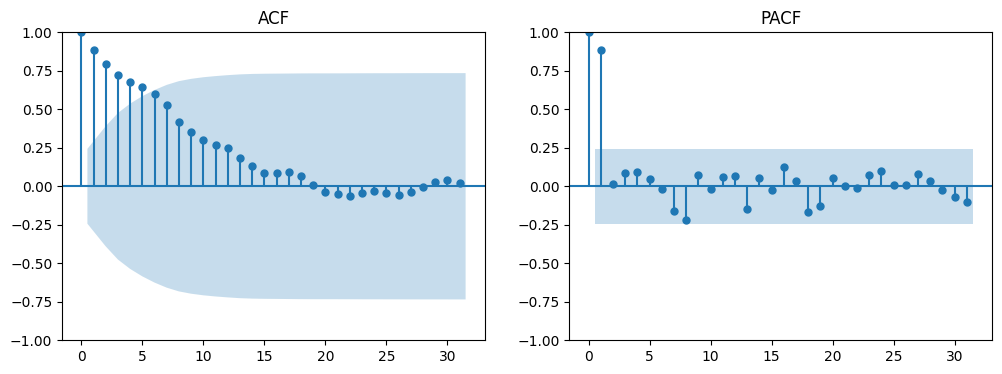


===== BARS — National Urban Supermarkets =====
Observations: 65


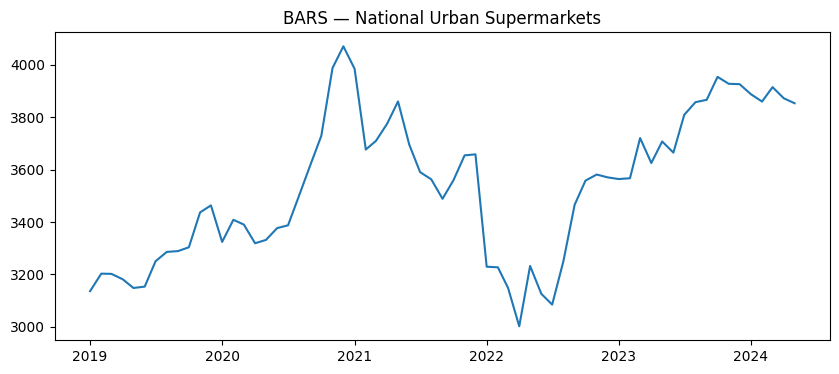

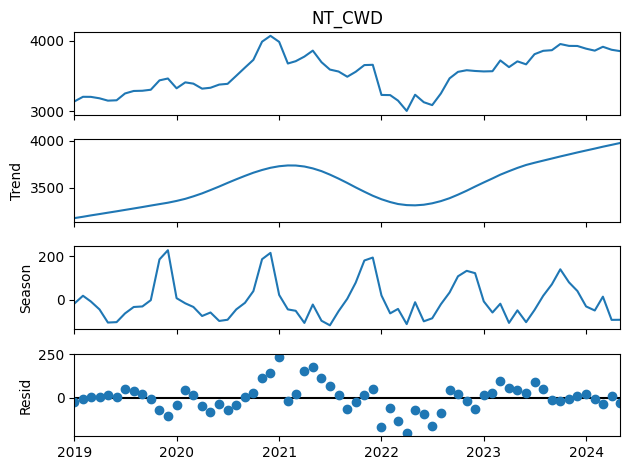

ADF statistic: -1.7512071389342452
p-value: 0.40494064630893123
Ряд нестационарный


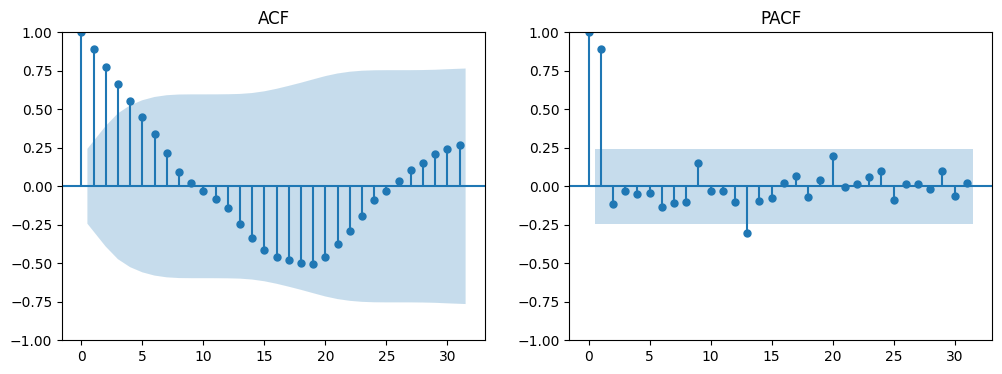


===== BITESIZE — Discounters =====
Observations: 65


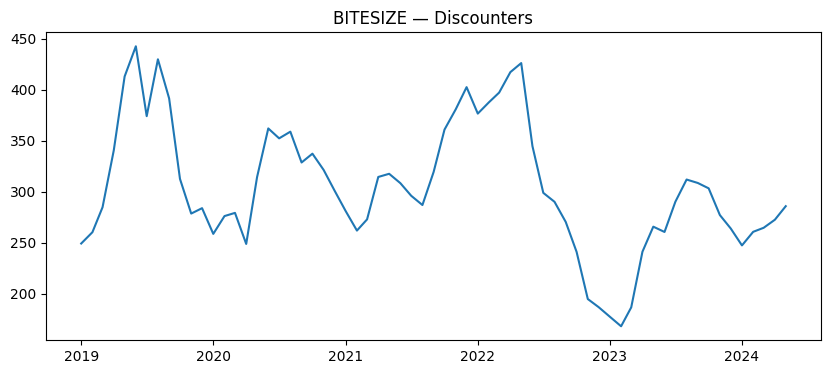

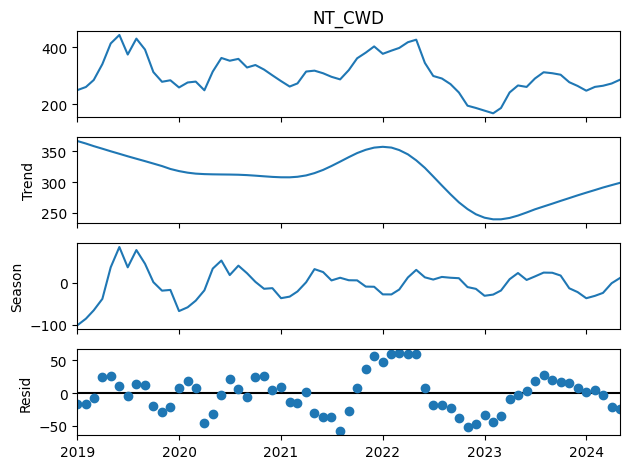

ADF statistic: -2.8899198634629957
p-value: 0.046532799544729456
Ряд стационарный


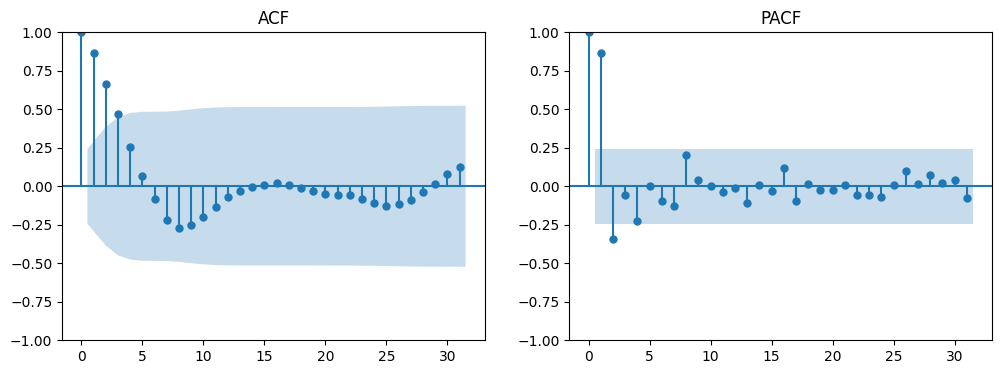


===== BITESIZE — National Urban Hypermarkets =====
Observations: 65


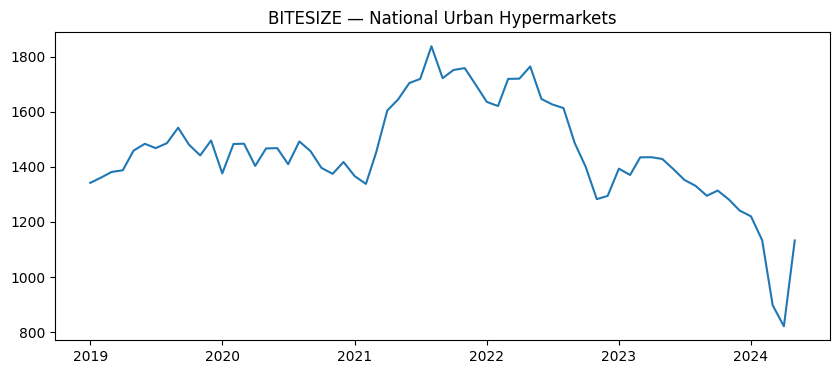

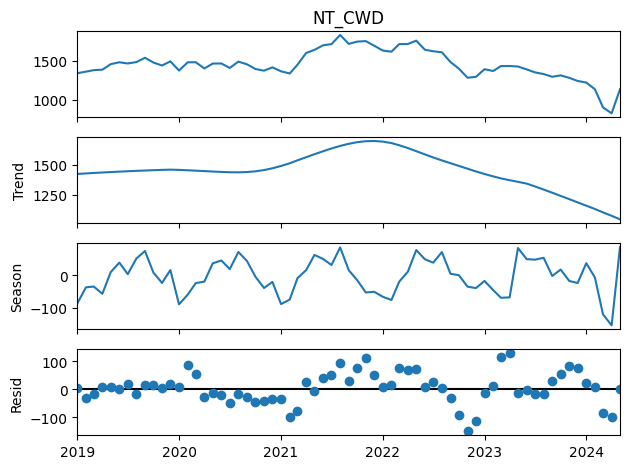

ADF statistic: -1.3204392051594394
p-value: 0.619770253798279
Ряд нестационарный


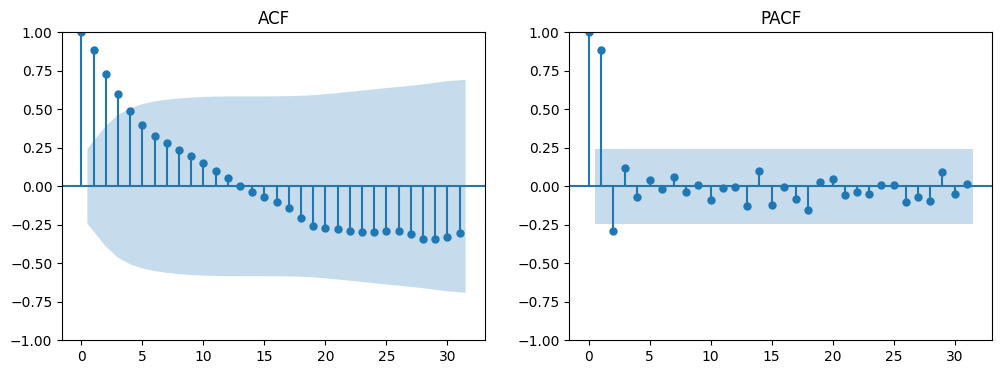


===== BITESIZE — National Urban Minimarkets =====
Observations: 65


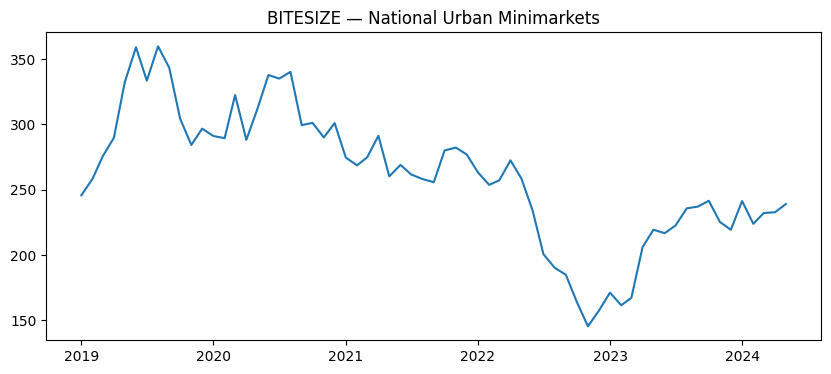

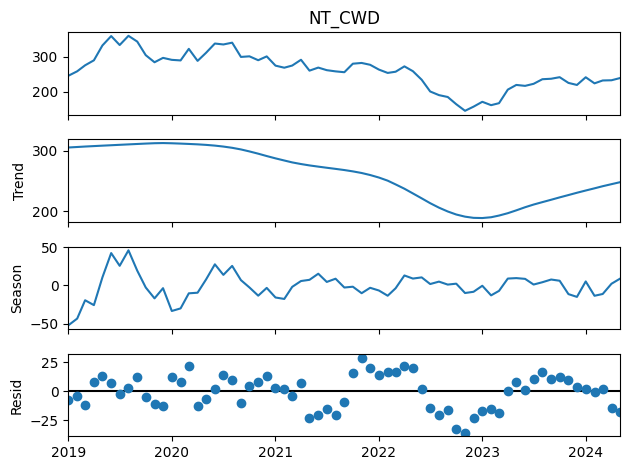

ADF statistic: -1.4358300813381013
p-value: 0.5649833612813218
Ряд нестационарный


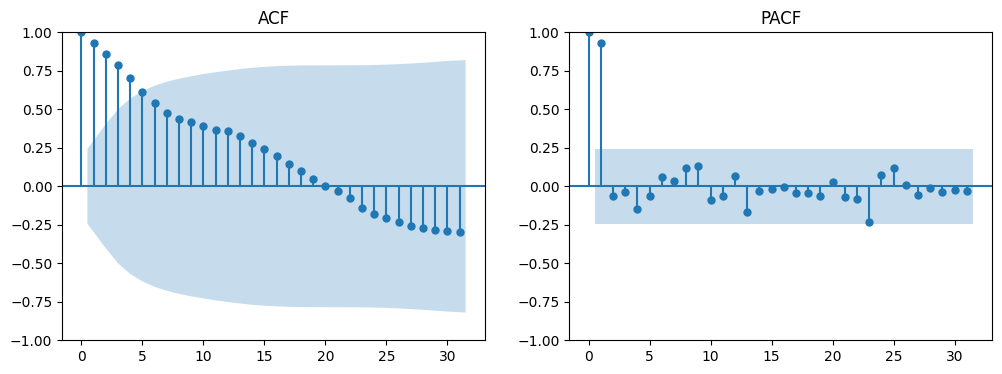


===== BITESIZE — National Urban Supermarkets =====
Observations: 65


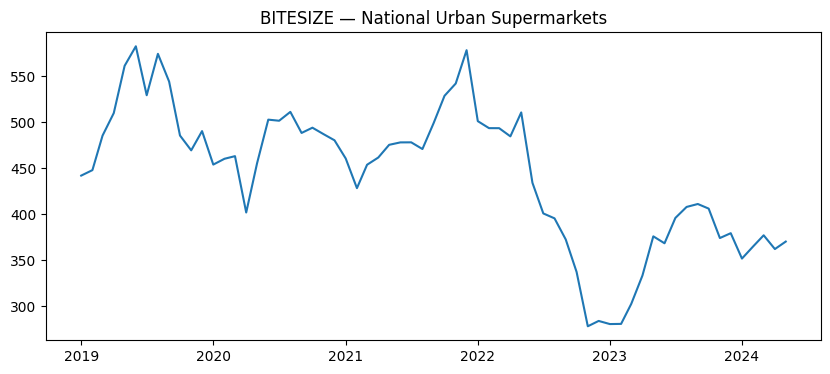

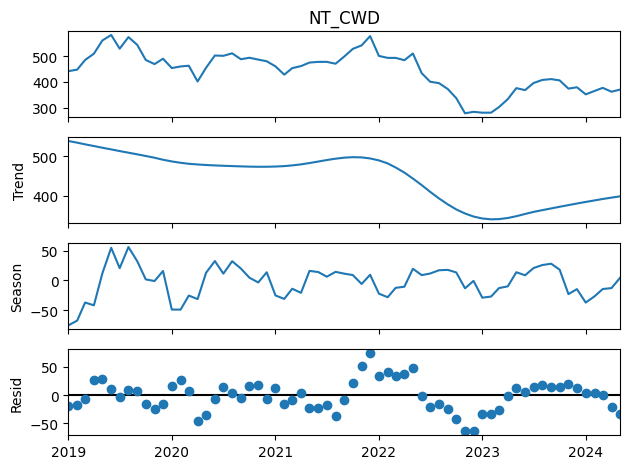

ADF statistic: -1.1145643596333055
p-value: 0.7092289974946624
Ряд нестационарный


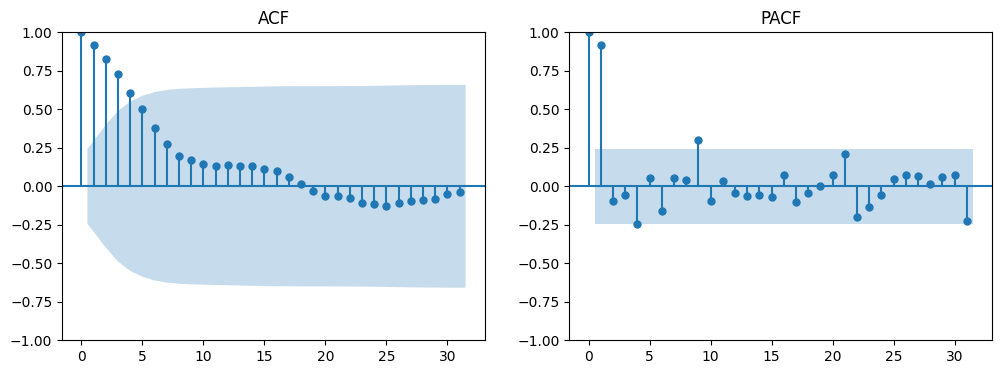


===== BOXED CHOCOLATE — Discounters =====
Observations: 65


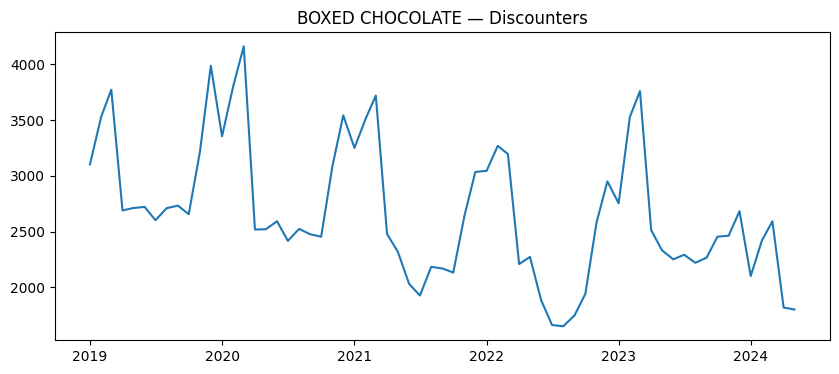

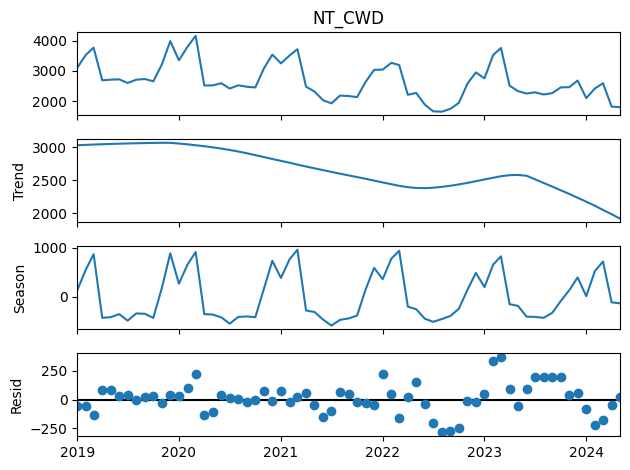

ADF statistic: -0.4386921714219353
p-value: 0.9034353816029013
Ряд нестационарный


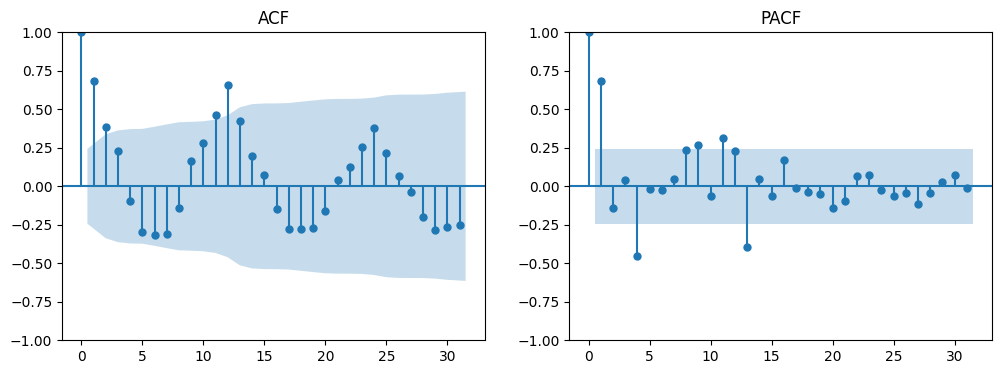


===== BOXED CHOCOLATE — National Urban Hypermarkets =====
Observations: 65


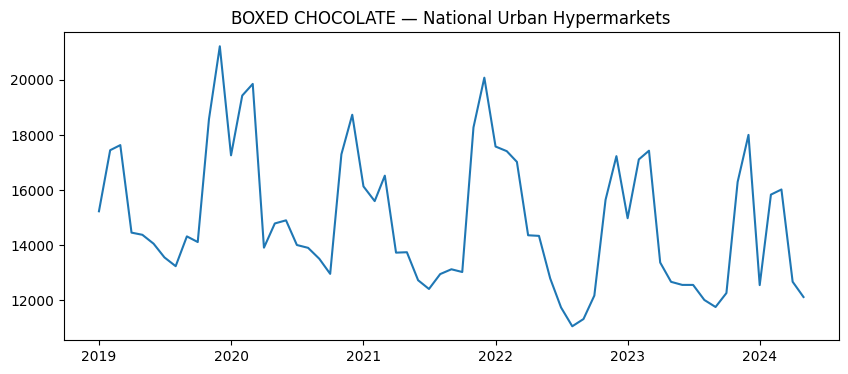

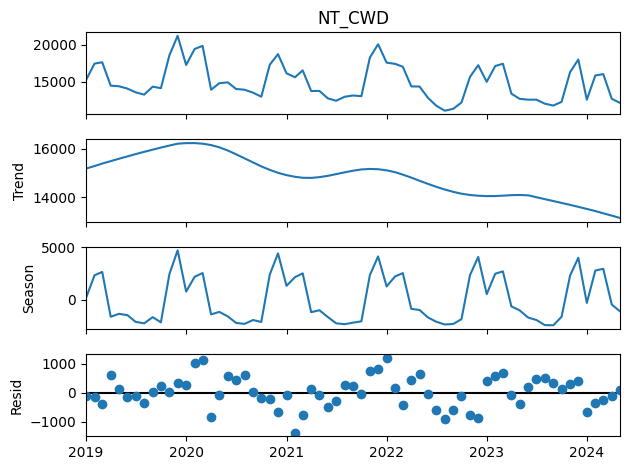

ADF statistic: -0.2362208697309933
p-value: 0.9340642069829284
Ряд нестационарный


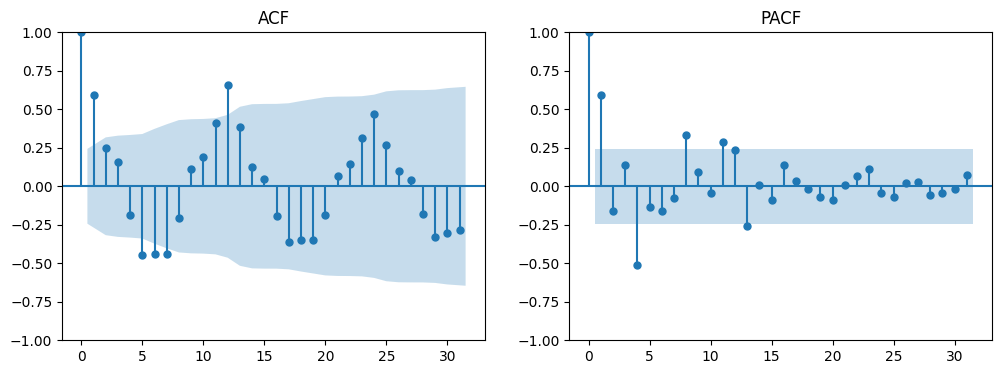


===== BOXED CHOCOLATE — National Urban Minimarkets =====
Observations: 65


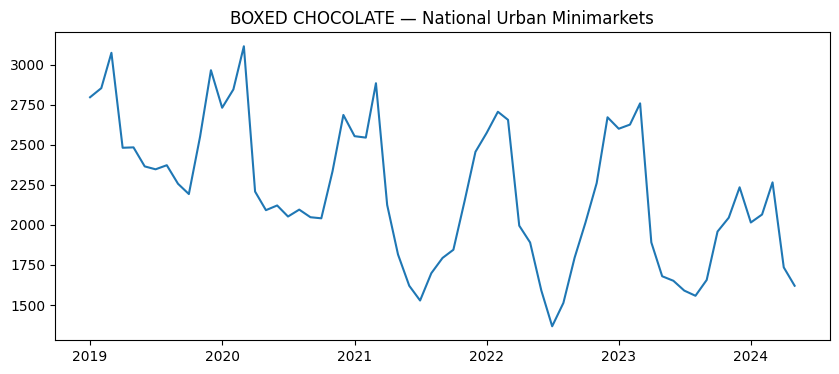

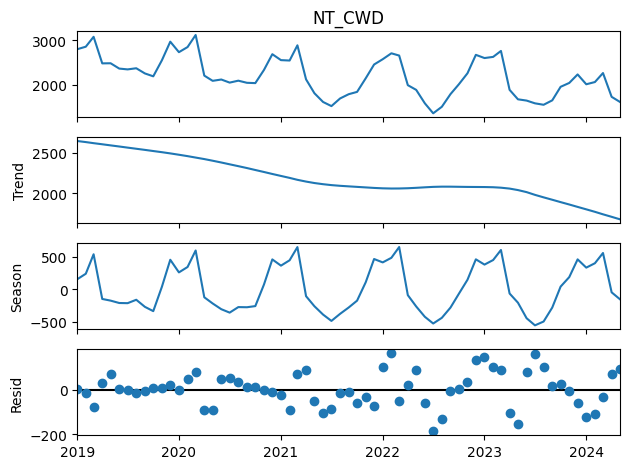

ADF statistic: -1.1590055145808658
p-value: 0.6909773844029932
Ряд нестационарный


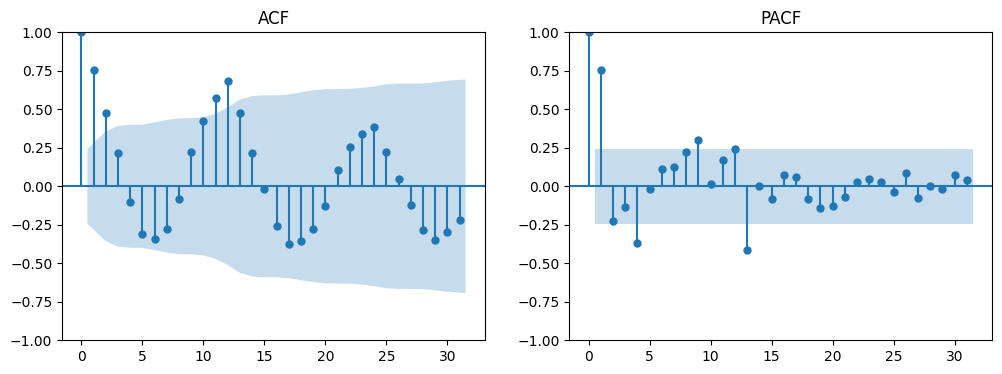


===== BOXED CHOCOLATE — National Urban Supermarkets =====
Observations: 65


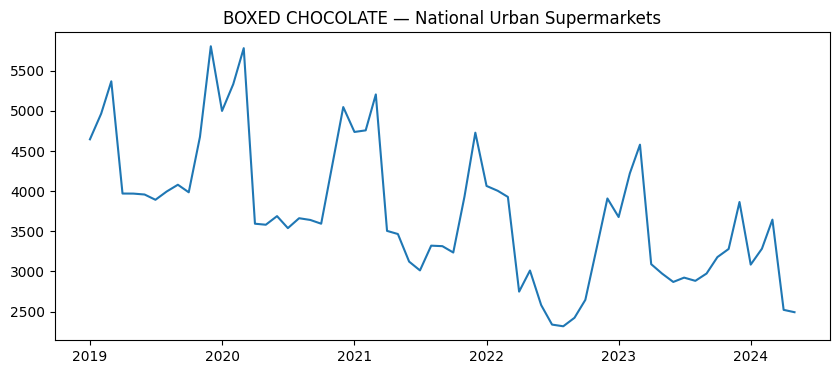

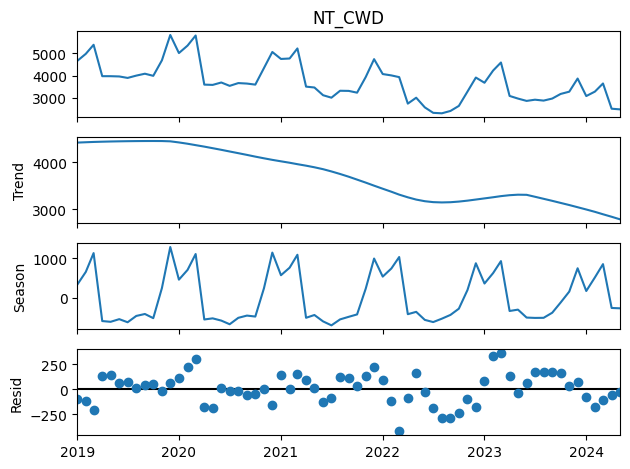

ADF statistic: -0.655367692479683
p-value: 0.8579741784816804
Ряд нестационарный


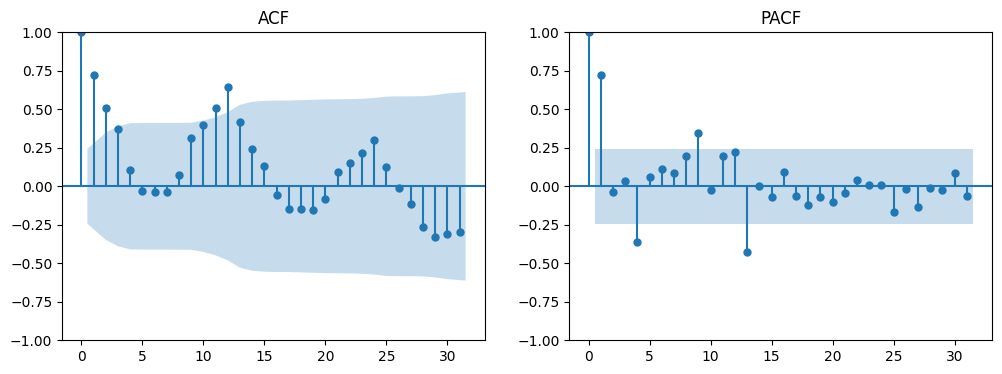


===== FRUITY CONFECTIONS — Discounters =====
Observations: 65


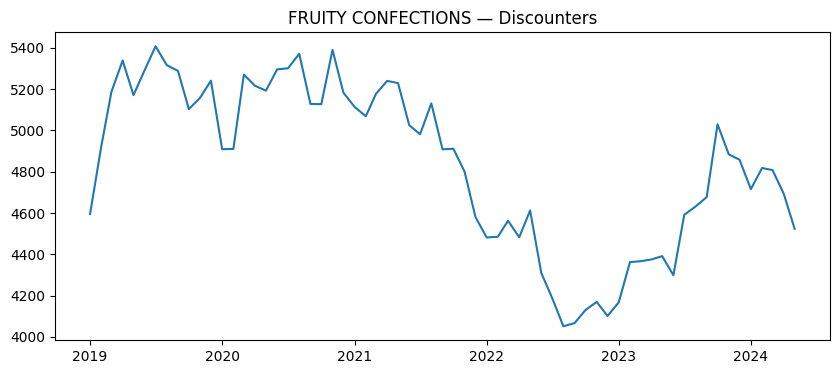

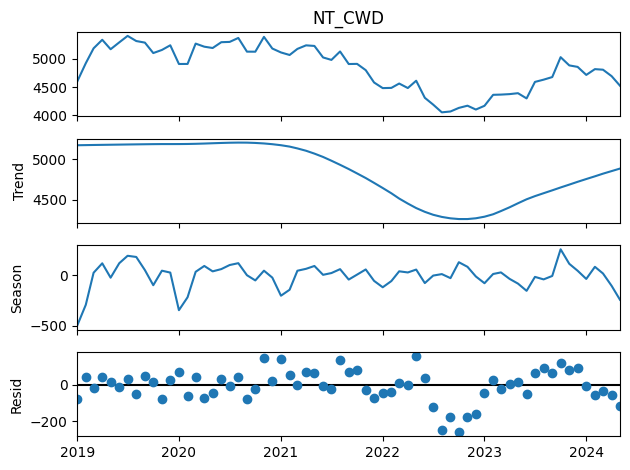

ADF statistic: -1.4870491312723306
p-value: 0.5399079438889145
Ряд нестационарный


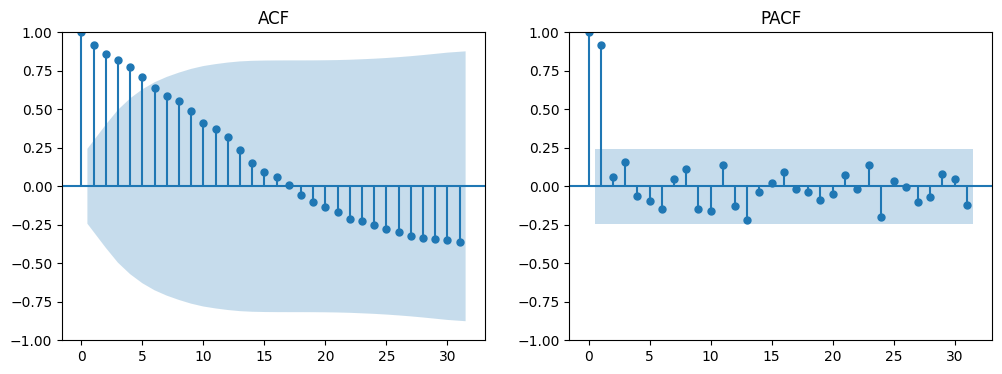


===== FRUITY CONFECTIONS — National Urban Hypermarkets =====
Observations: 65


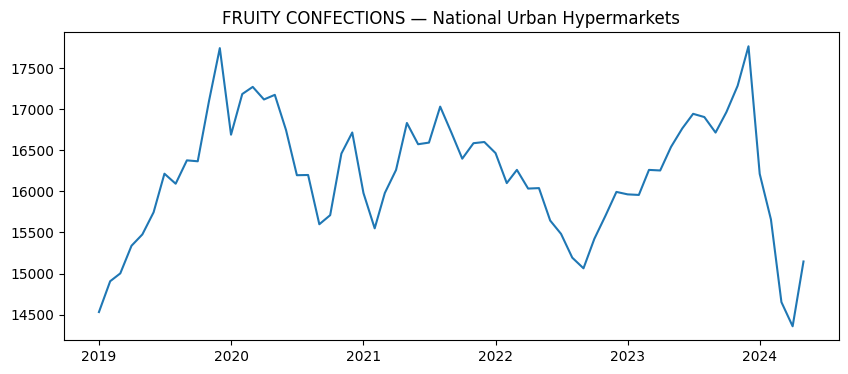

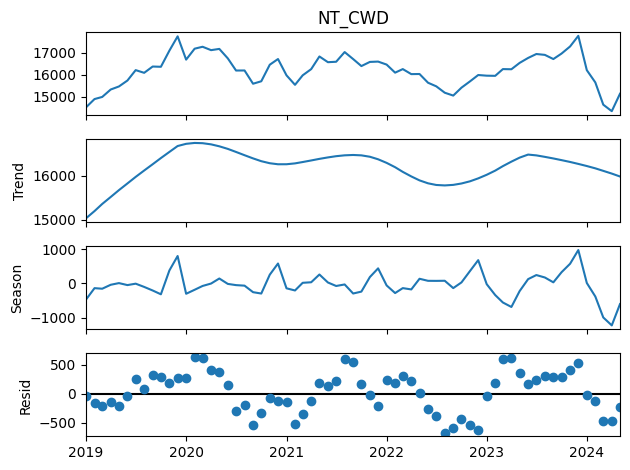

ADF statistic: -3.1160979836752714
p-value: 0.025384576421895302
Ряд стационарный


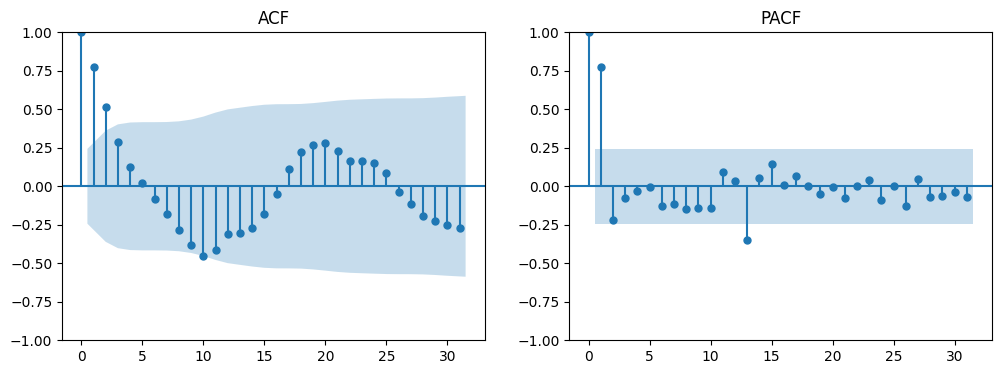


===== FRUITY CONFECTIONS — National Urban Minimarkets =====
Observations: 65


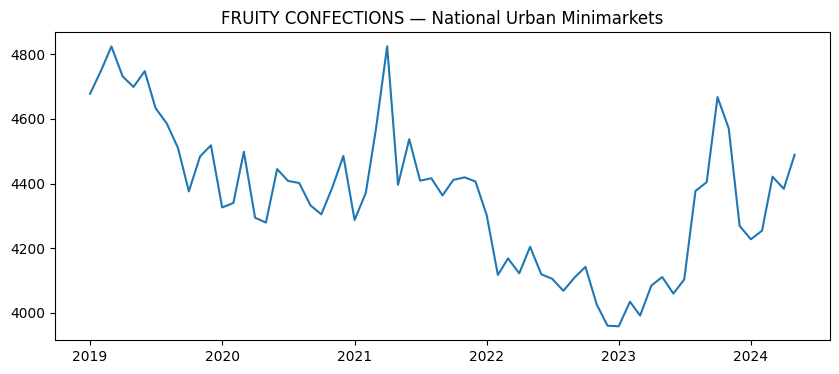

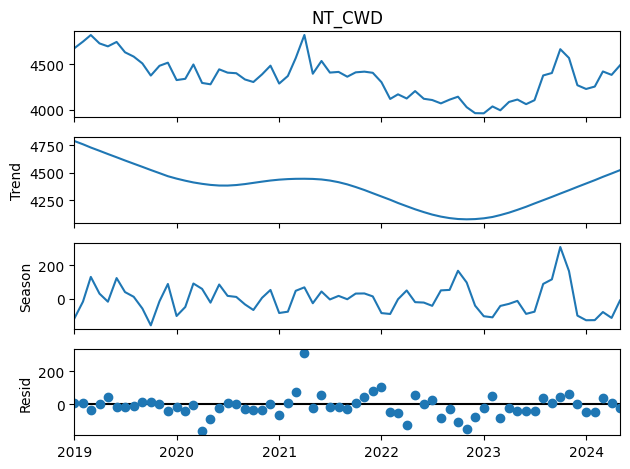

ADF statistic: -2.561364841239002
p-value: 0.10124813094234142
Ряд нестационарный


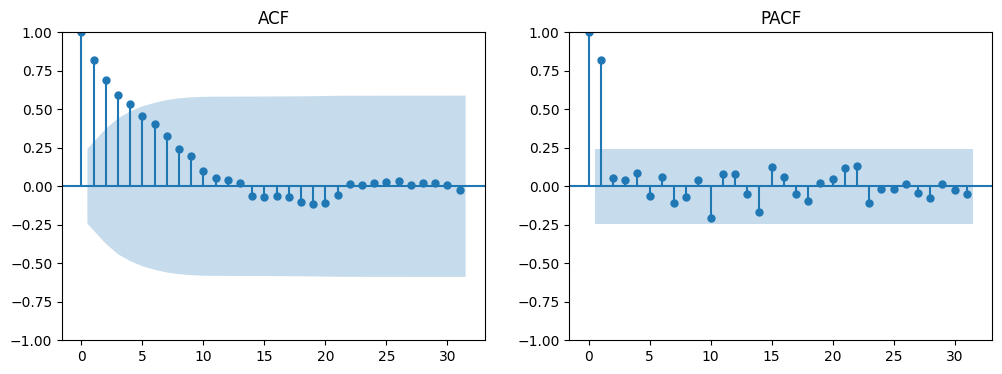


===== FRUITY CONFECTIONS — National Urban Supermarkets =====
Observations: 65


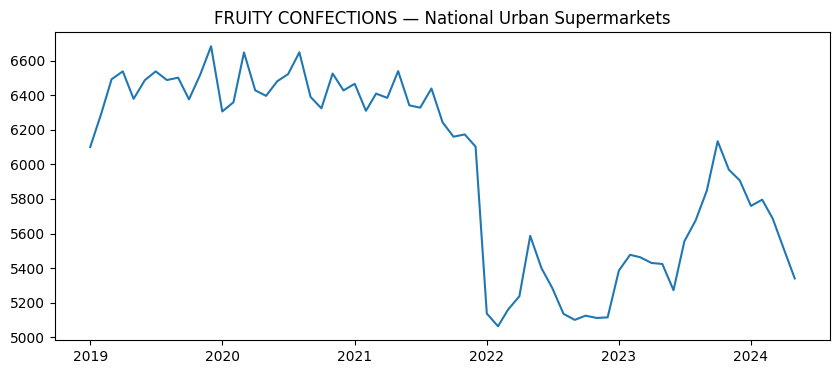

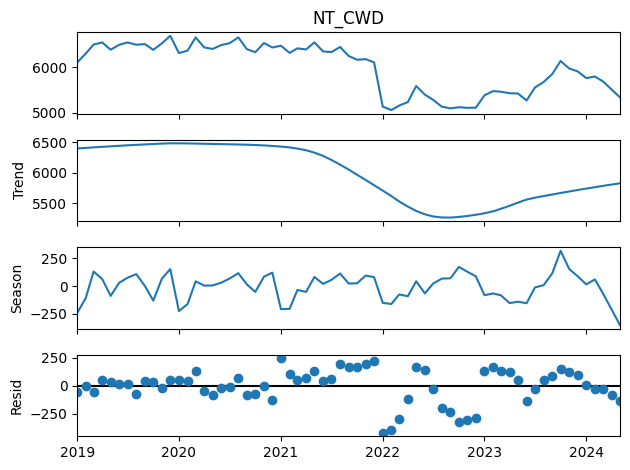

ADF statistic: -1.2063674761157184
p-value: 0.6708506038635929
Ряд нестационарный


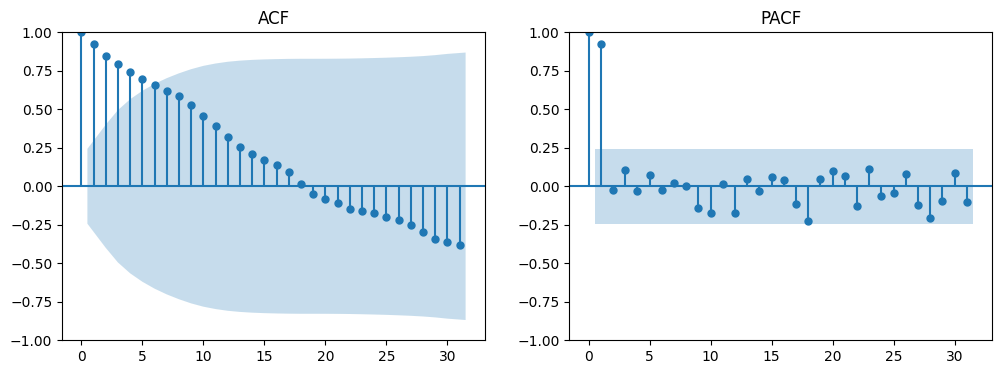


===== GUM — Discounters =====
Observations: 65


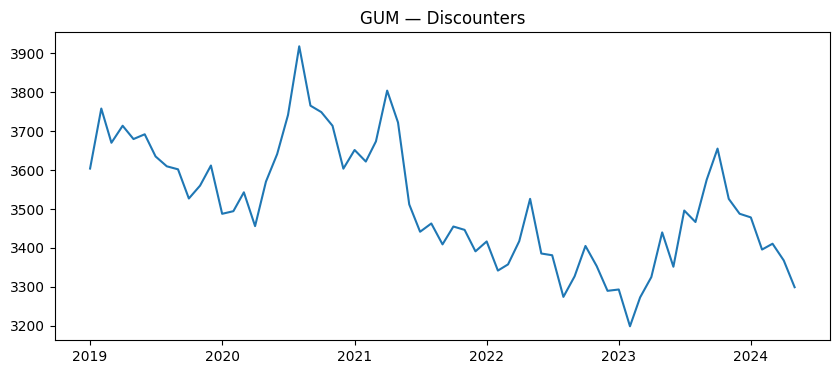

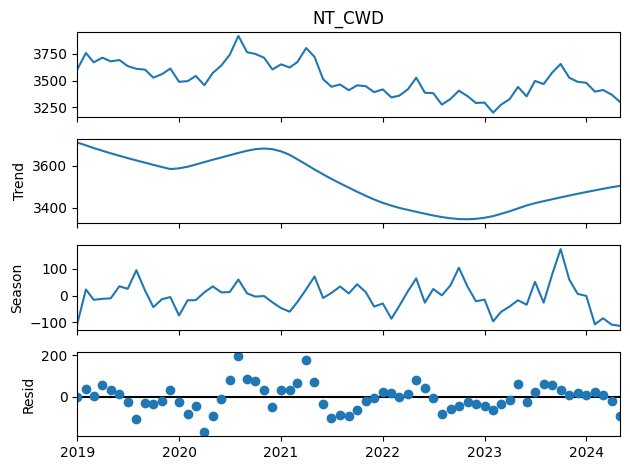

ADF statistic: -1.9869667548408745
p-value: 0.2923167988659353
Ряд нестационарный


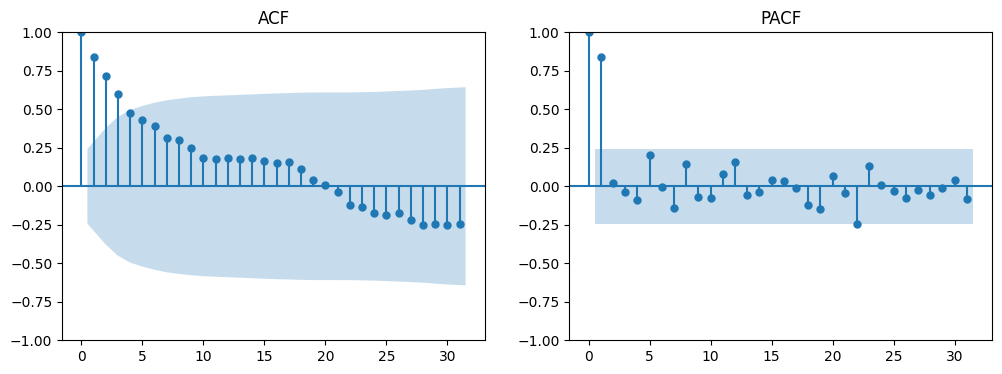


===== GUM — National Urban Hypermarkets =====
Observations: 65


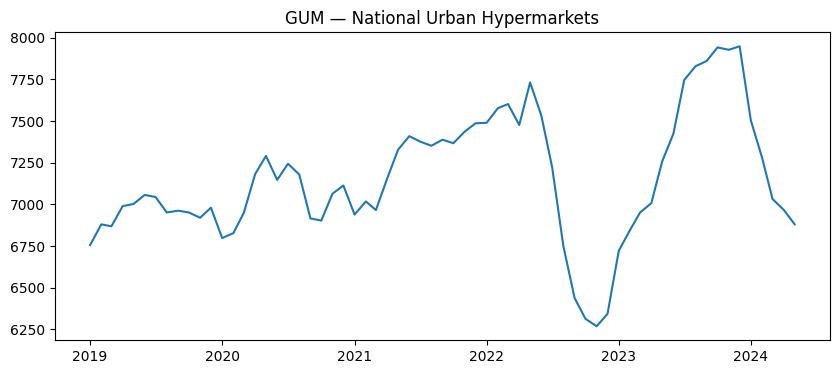

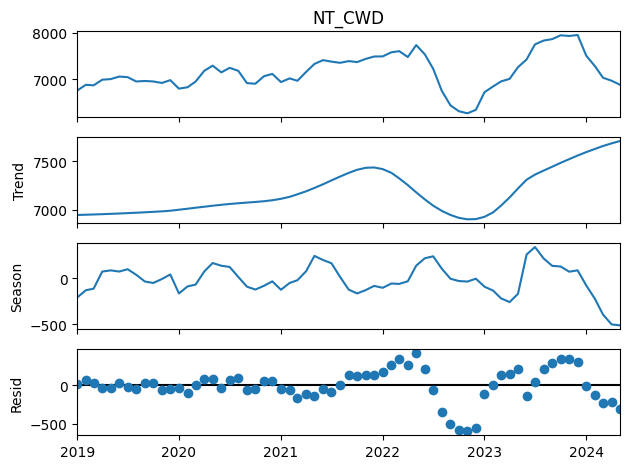

ADF statistic: -3.495588067613106
p-value: 0.008101127421564205
Ряд стационарный


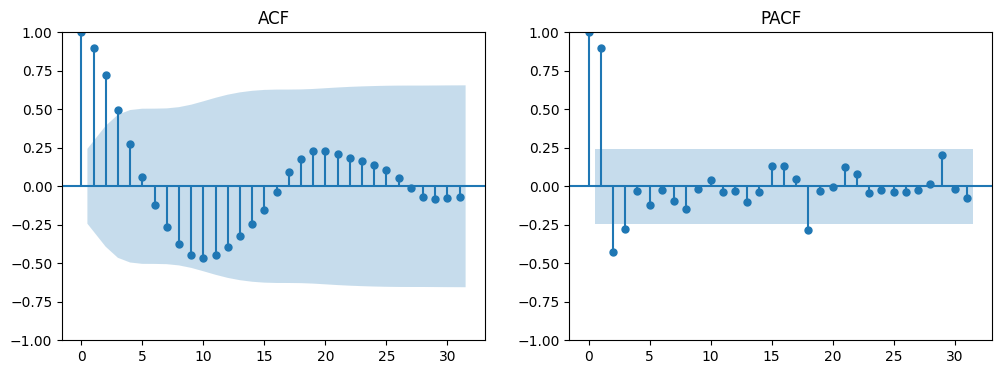


===== GUM — National Urban Minimarkets =====
Observations: 65


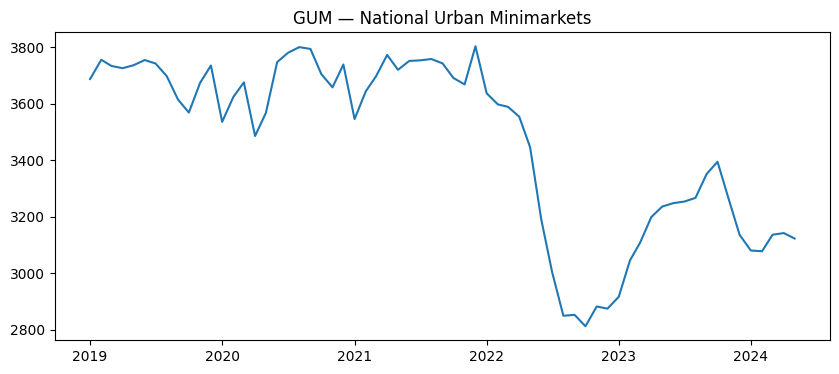

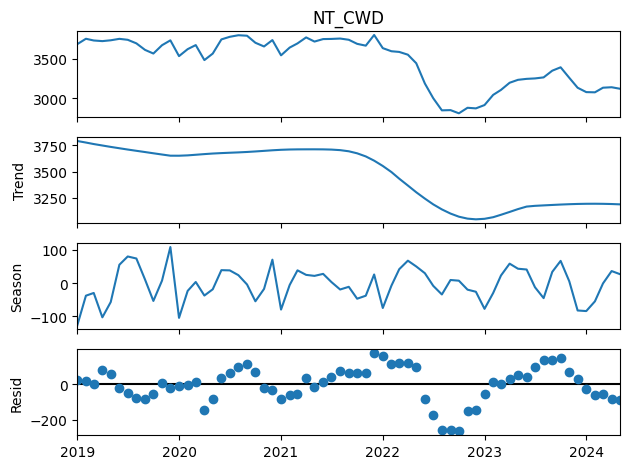

ADF statistic: -0.9974132673455107
p-value: 0.7542065828674058
Ряд нестационарный


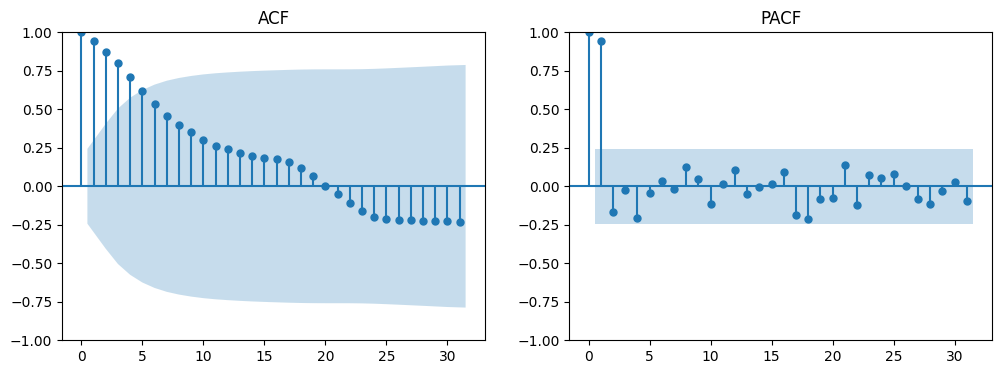


===== GUM — National Urban Supermarkets =====
Observations: 65


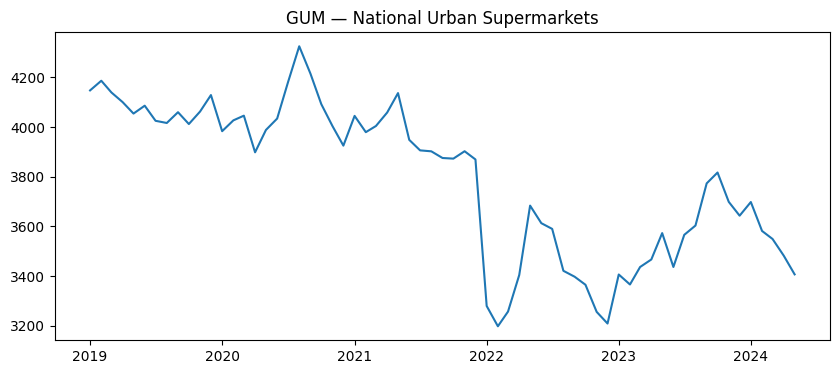

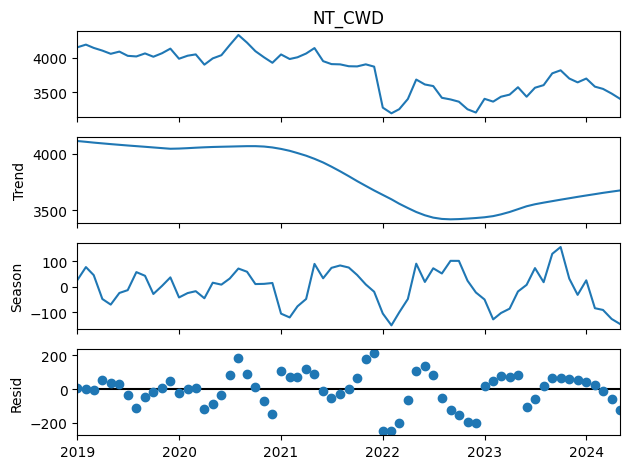

ADF statistic: -1.5419453313190001
p-value: 0.5126690475147376
Ряд нестационарный


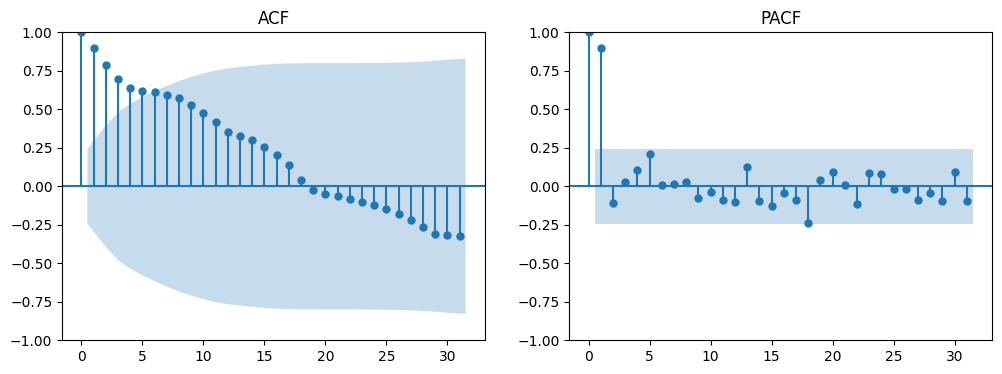


===== IMPULSE FANCY — Discounters =====
Observations: 65


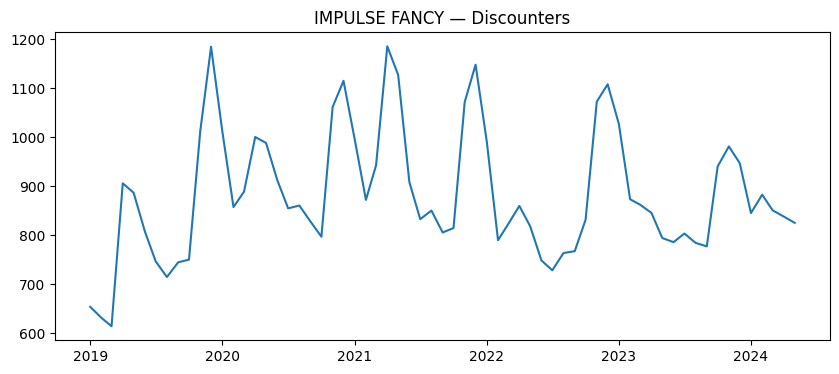

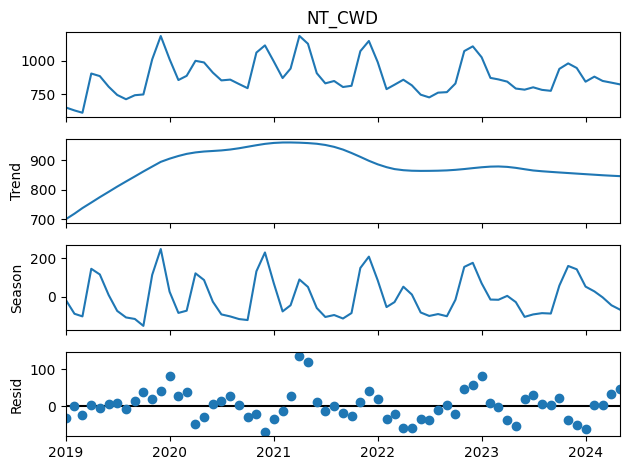

ADF statistic: -1.2042198233743964
p-value: 0.6717778212143751
Ряд нестационарный


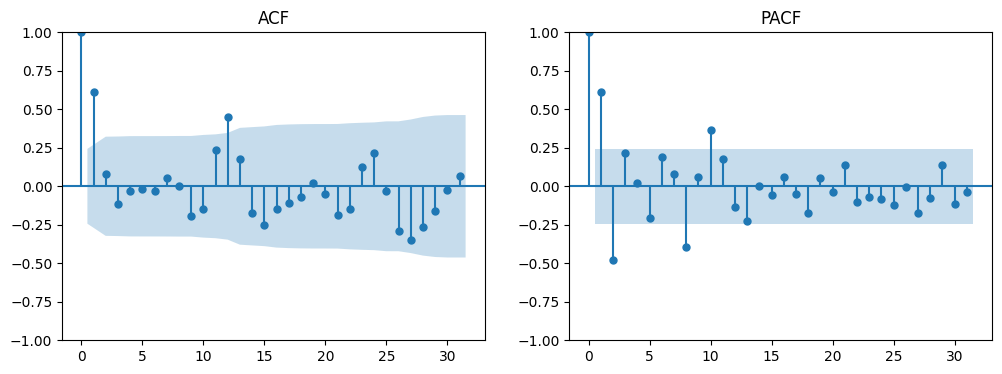


===== IMPULSE FANCY — National Urban Hypermarkets =====
Observations: 65


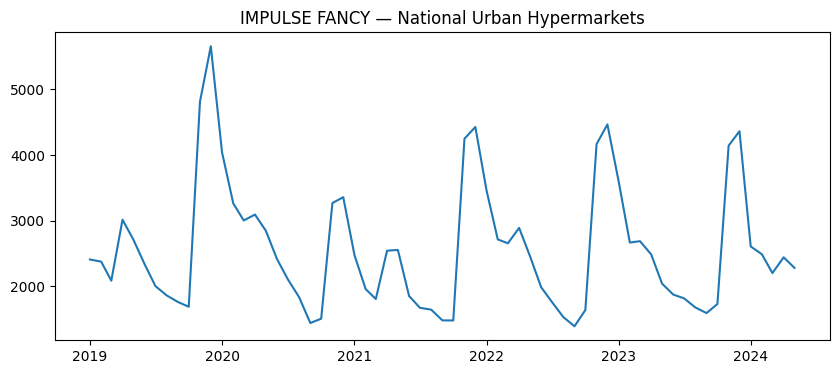

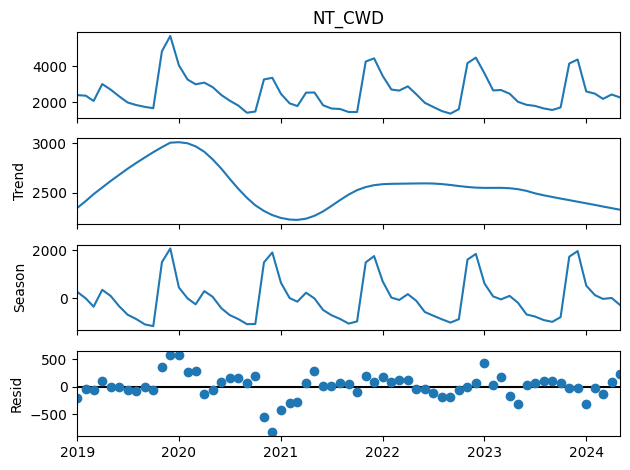

ADF statistic: -1.25155436286555
p-value: 0.6510348103917676
Ряд нестационарный


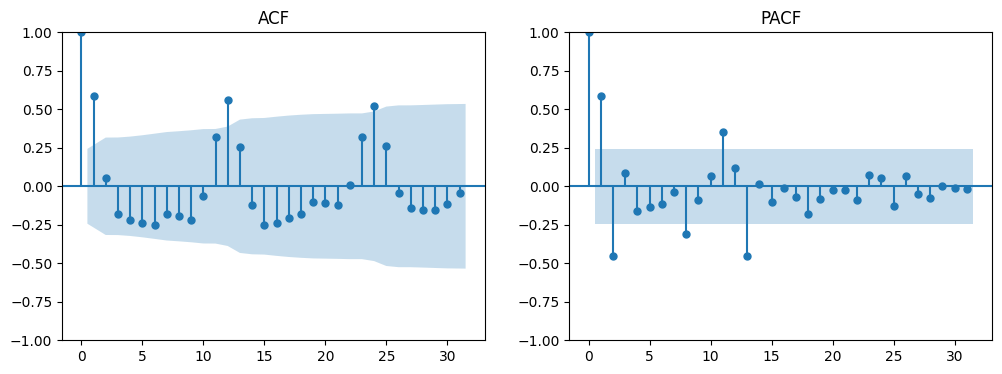


===== IMPULSE FANCY — National Urban Minimarkets =====
Observations: 65


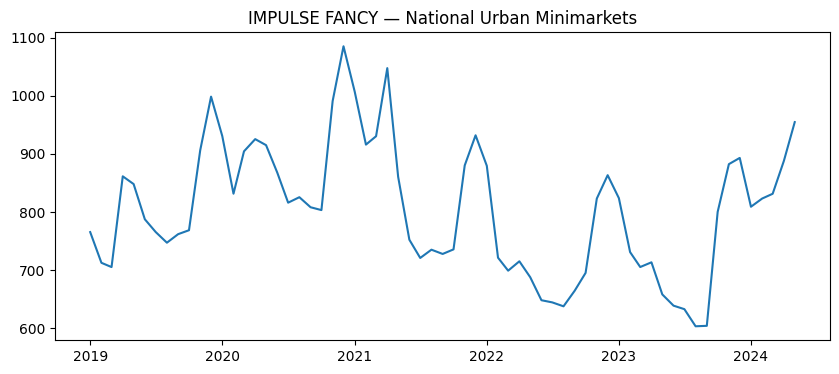

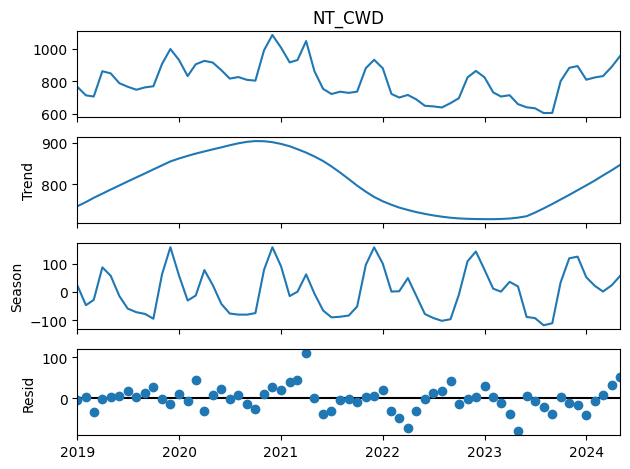

ADF statistic: -1.1682174316886245
p-value: 0.6871162173117162
Ряд нестационарный


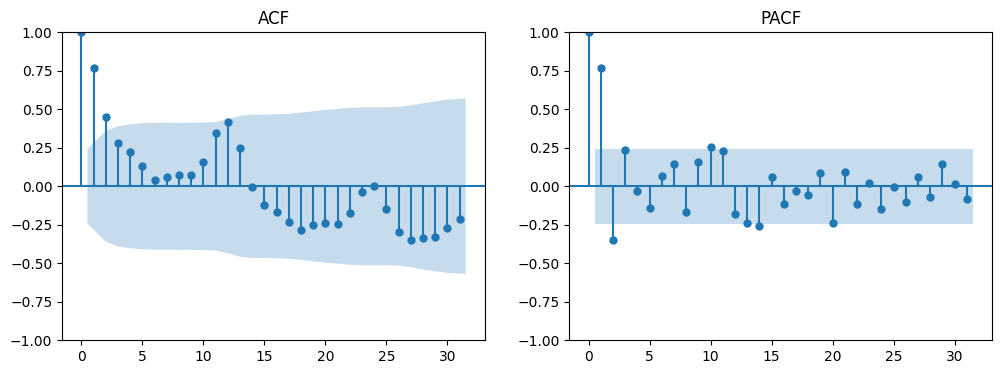


===== IMPULSE FANCY — National Urban Supermarkets =====
Observations: 65


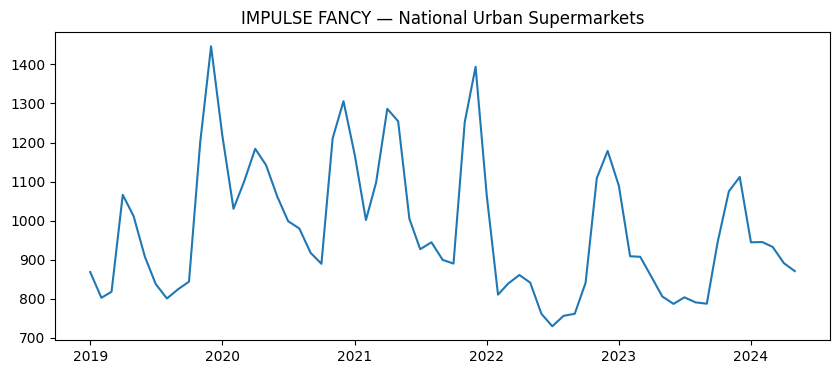

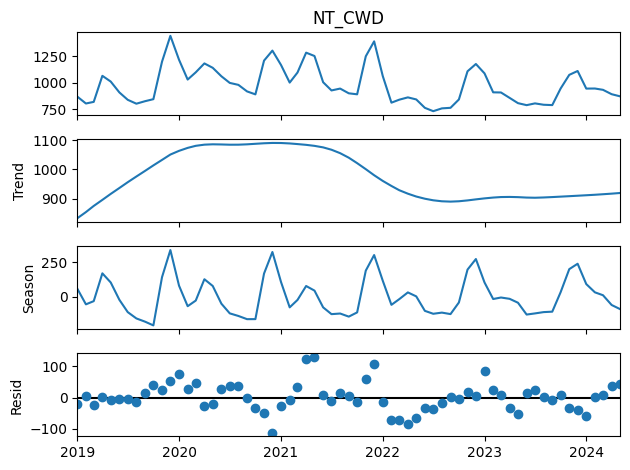

ADF statistic: -0.6670502887503398
p-value: 0.8551006783739248
Ряд нестационарный


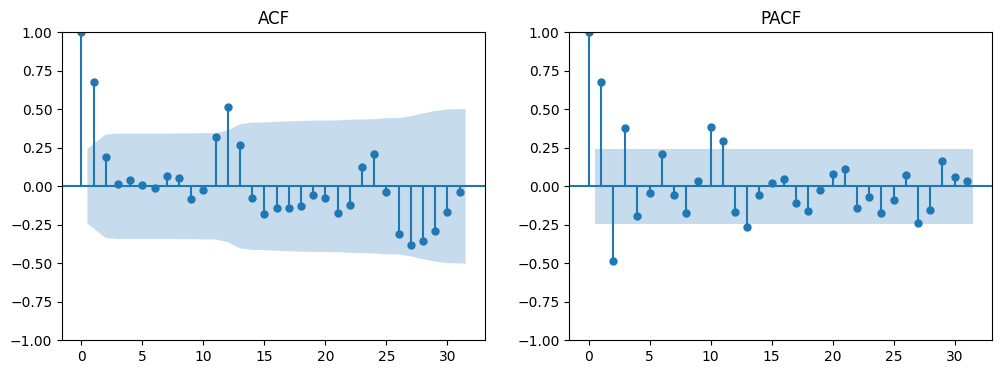


===== MEDICINAL — Discounters =====
Observations: 65


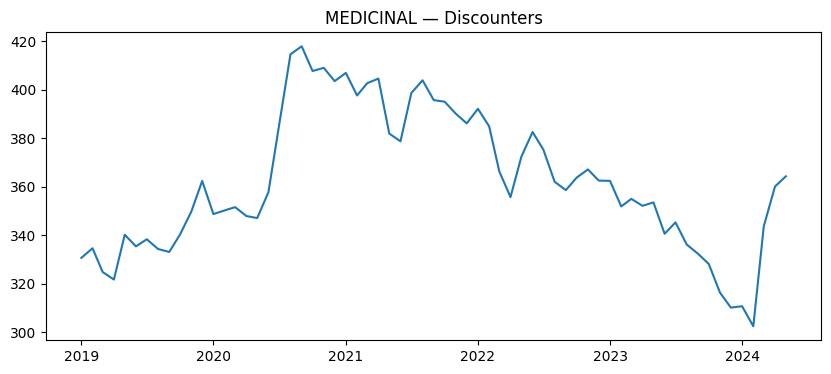

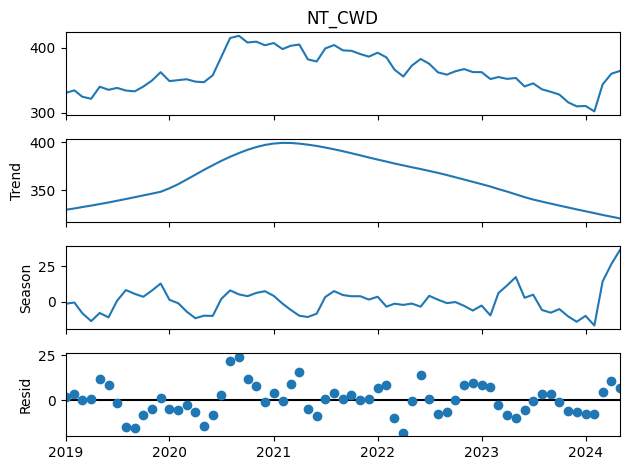

ADF statistic: -2.065859017027207
p-value: 0.2584625325076678
Ряд нестационарный


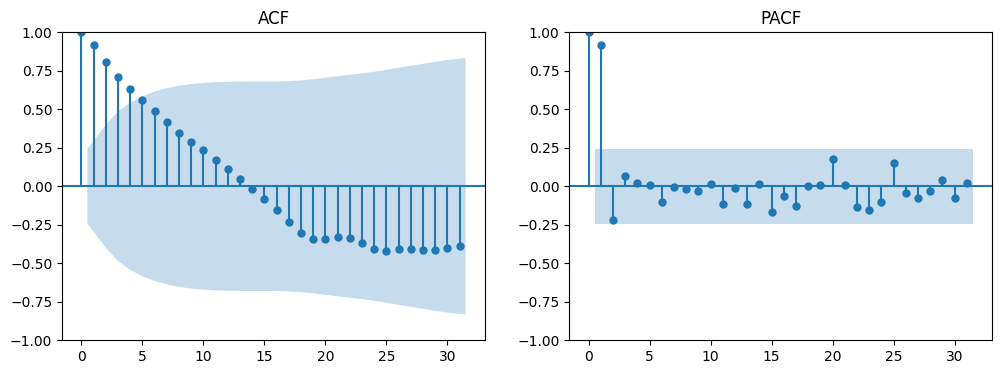


===== MEDICINAL — National Urban Hypermarkets =====
Observations: 65


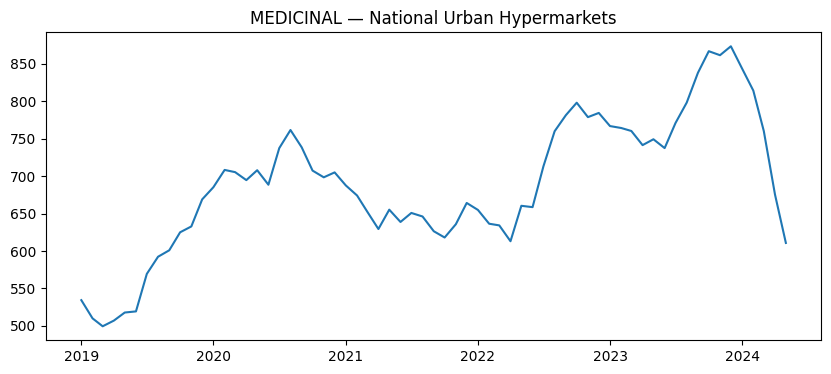

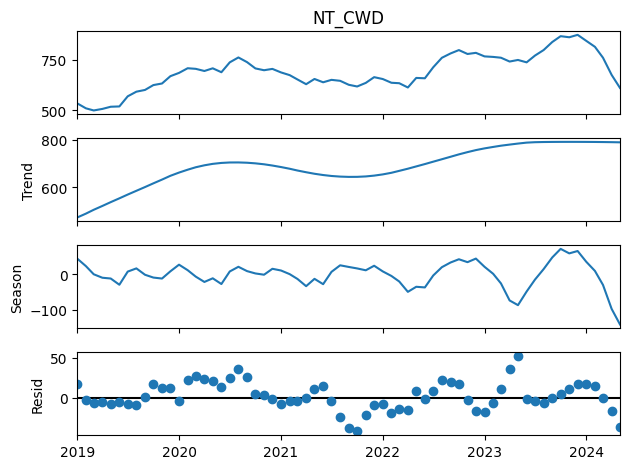

ADF statistic: -3.0713062779404647
p-value: 0.02875082129383543
Ряд стационарный


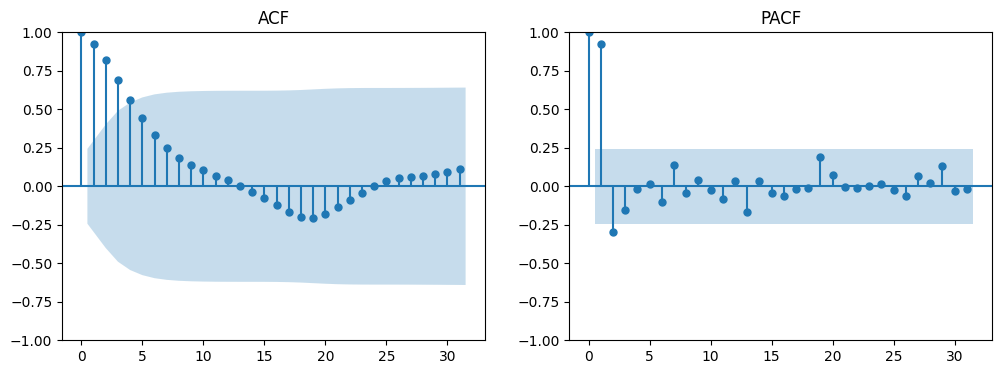


===== MEDICINAL — National Urban Minimarkets =====
Observations: 65


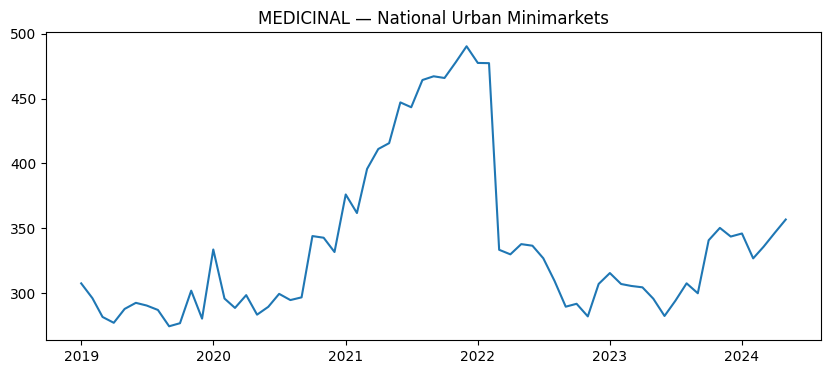

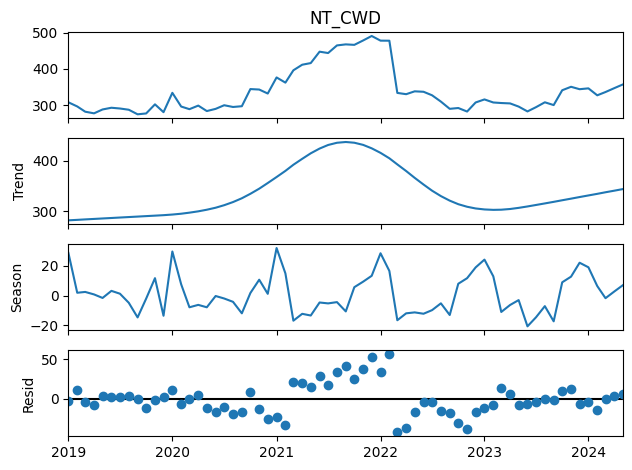

ADF statistic: -1.6599115600446106
p-value: 0.451876519085902
Ряд нестационарный


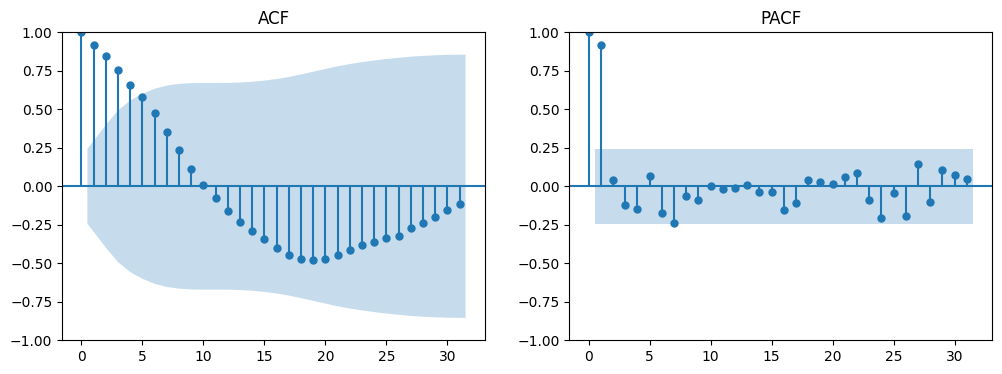


===== MEDICINAL — National Urban Supermarkets =====
Observations: 65


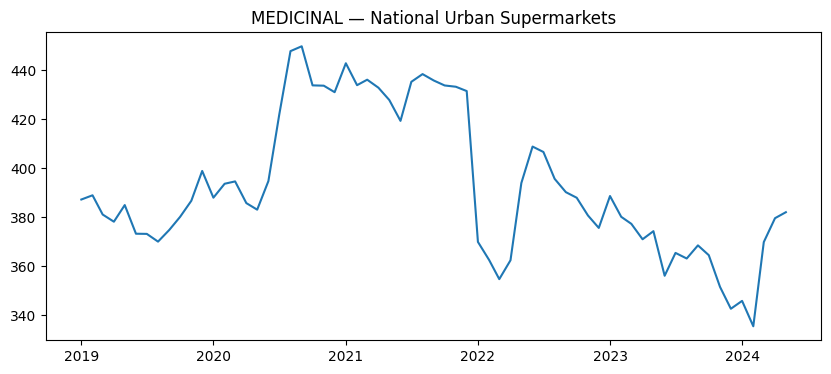

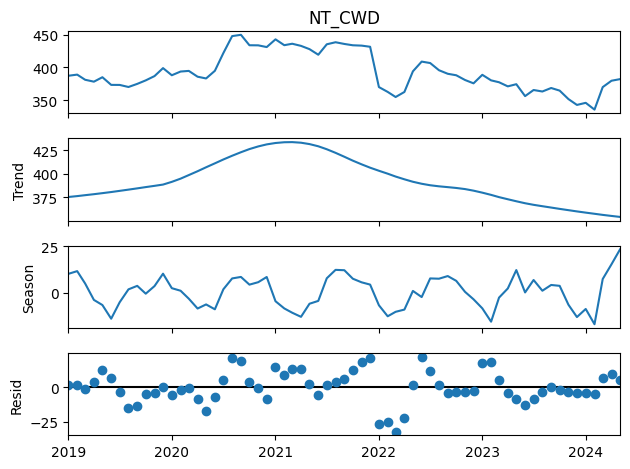

ADF statistic: -2.1443750562643062
p-value: 0.22704938010886128
Ряд нестационарный


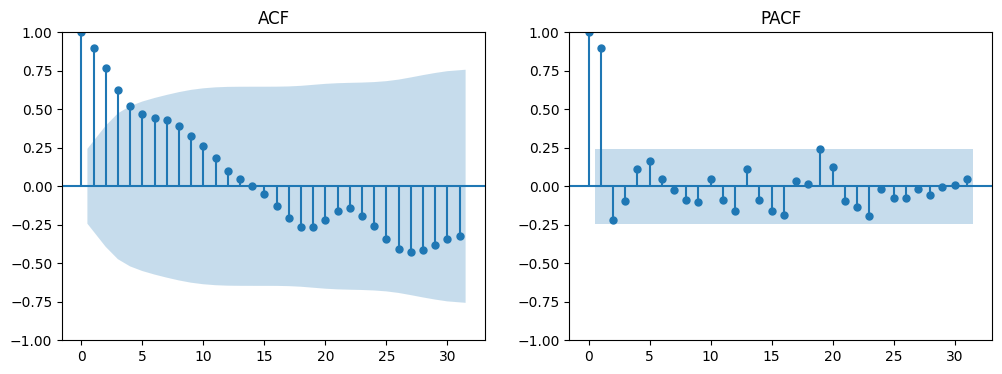


===== MINTS — Discounters =====
Observations: 65


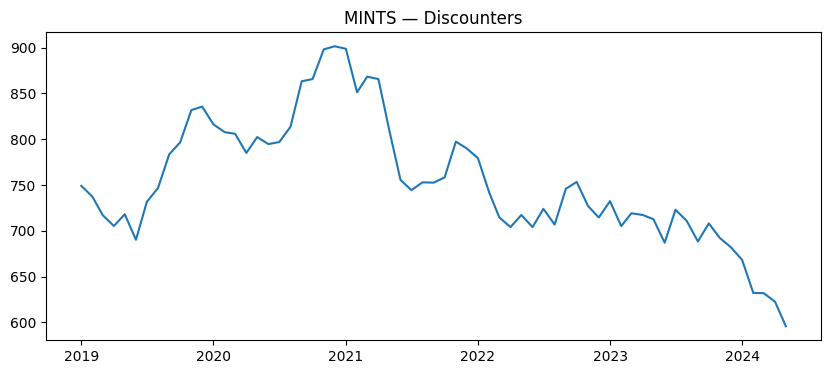

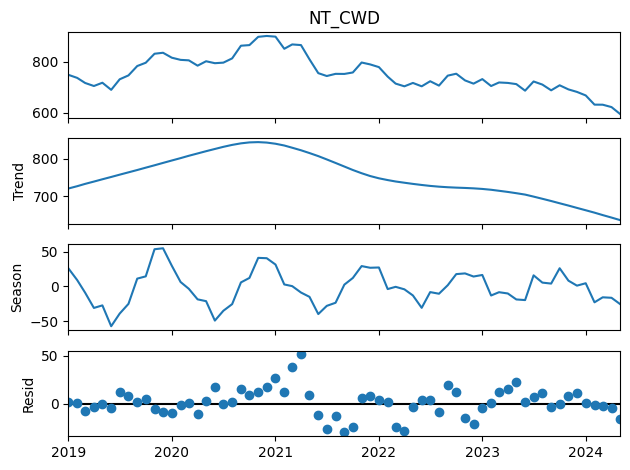

ADF statistic: -0.36287668568024256
p-value: 0.9161149697150466
Ряд нестационарный


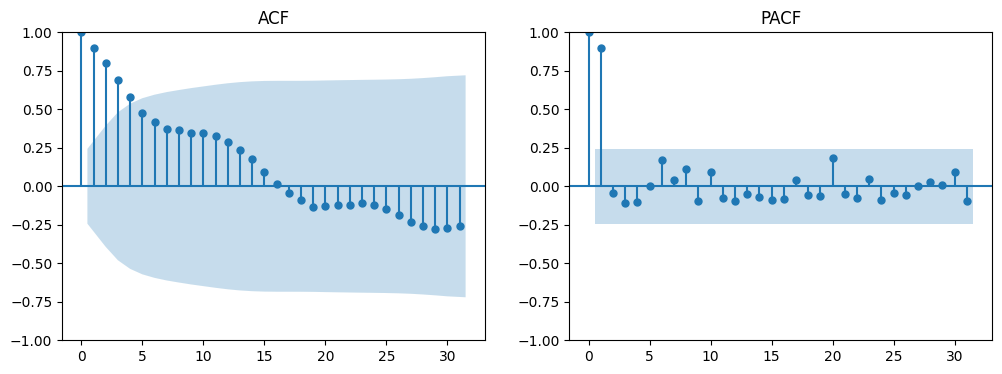


===== MINTS — National Urban Hypermarkets =====
Observations: 65


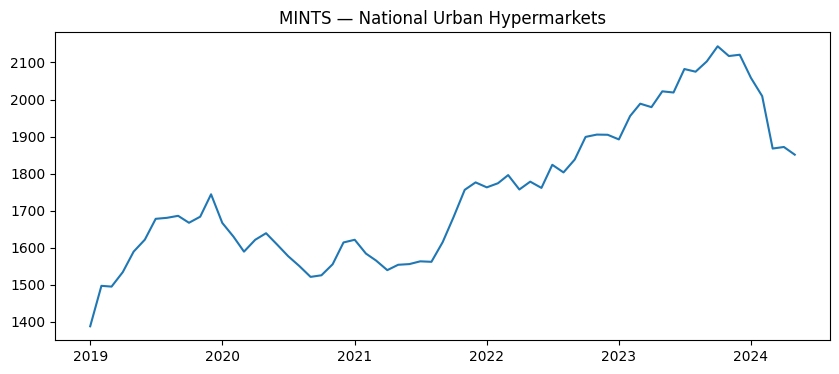

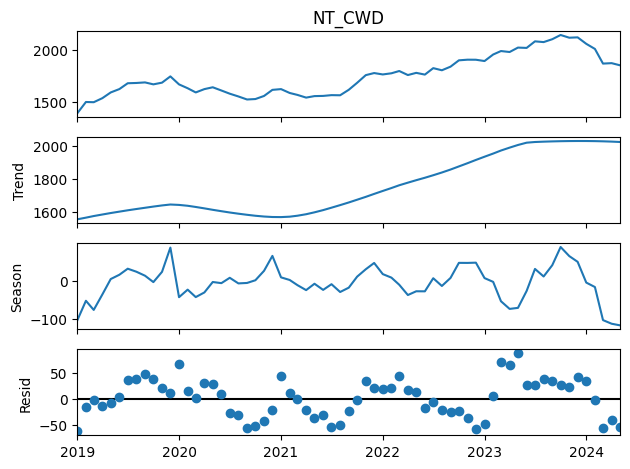

ADF statistic: -1.579199195075713
p-value: 0.4940334420965493
Ряд нестационарный


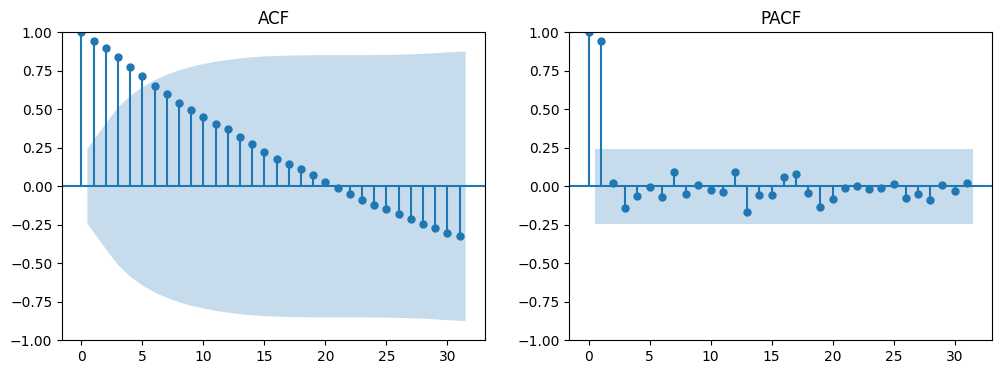


===== MINTS — National Urban Minimarkets =====
Observations: 65


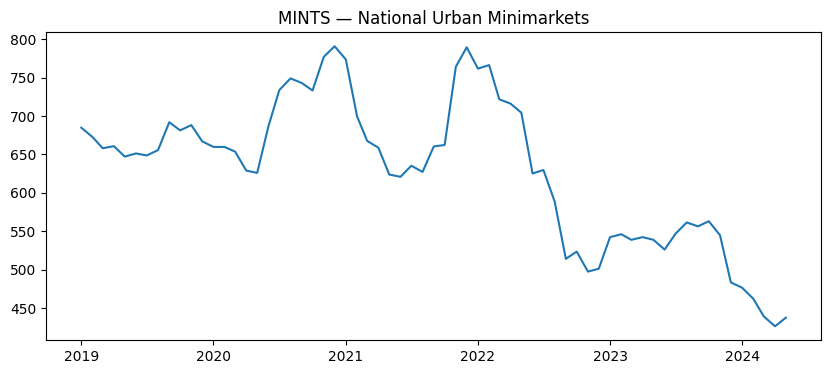

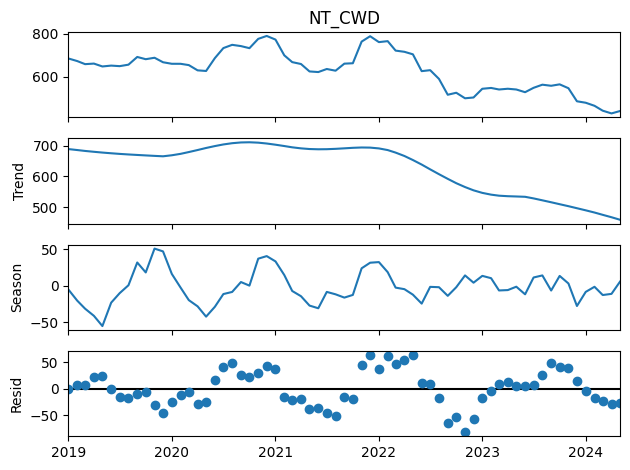

ADF statistic: -0.43516998160601117
p-value: 0.904058975963151
Ряд нестационарный


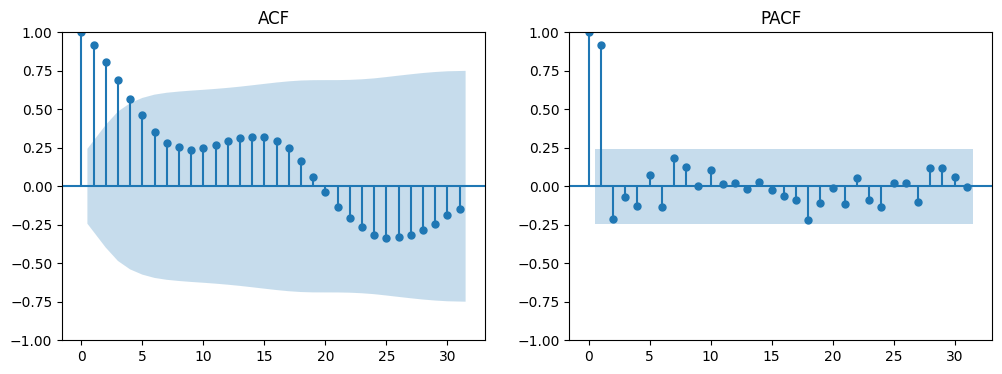


===== MINTS — National Urban Supermarkets =====
Observations: 65


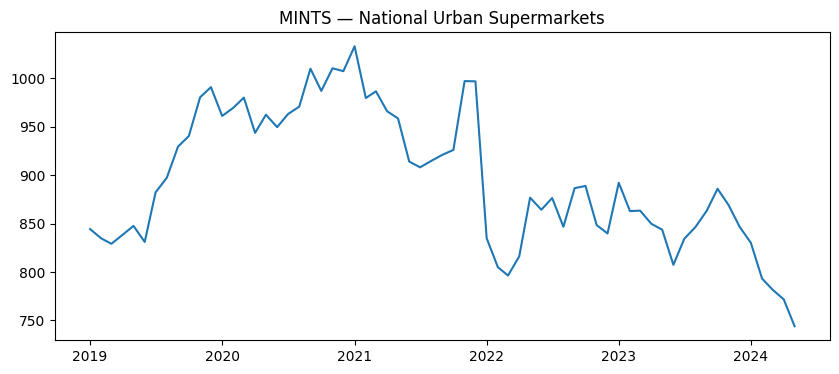

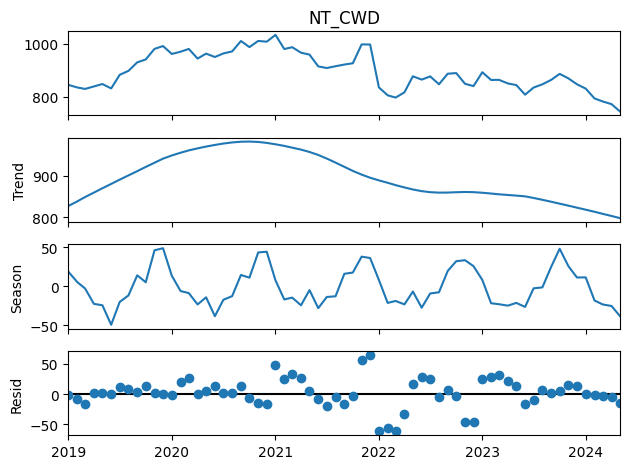

ADF statistic: -1.352697671764617
p-value: 0.6047318454617048
Ряд нестационарный


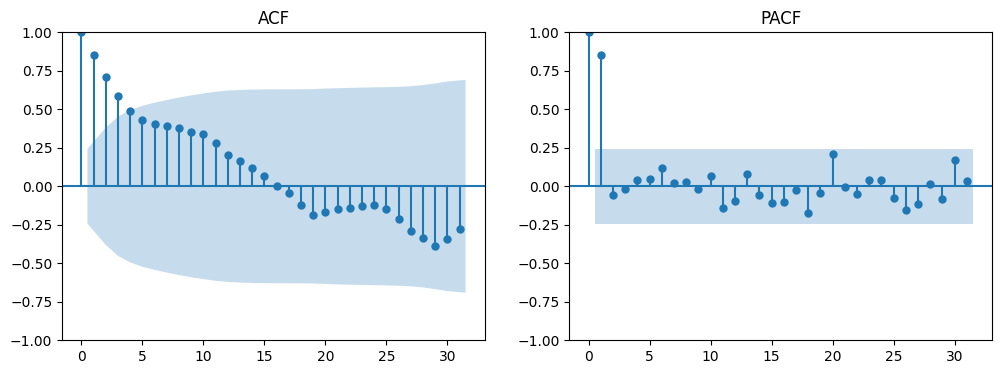


===== TABLETS — Discounters =====
Observations: 65


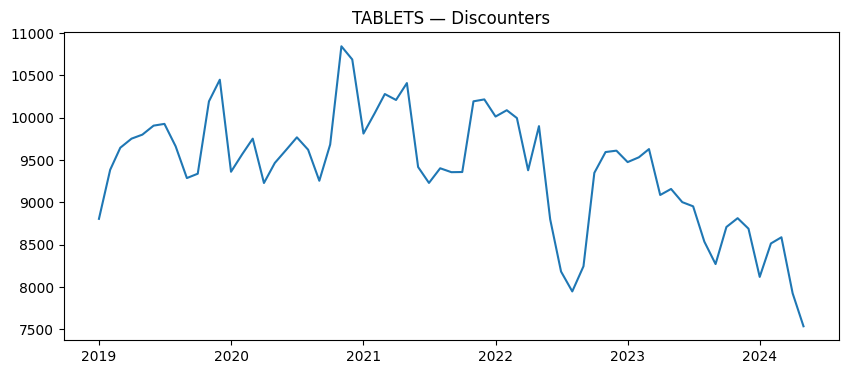

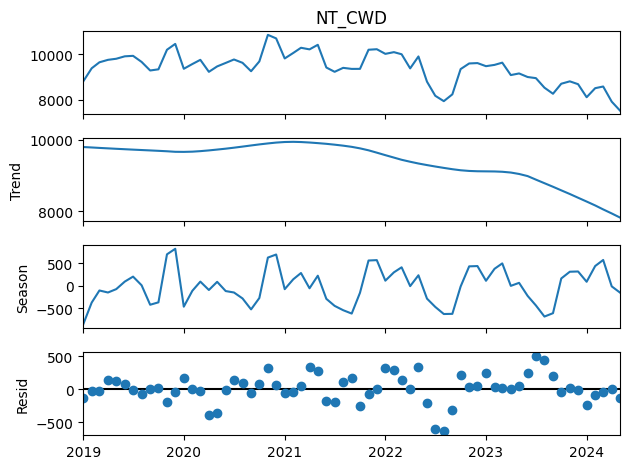

ADF statistic: 1.839543913531672
p-value: 0.9984243041102997
Ряд нестационарный


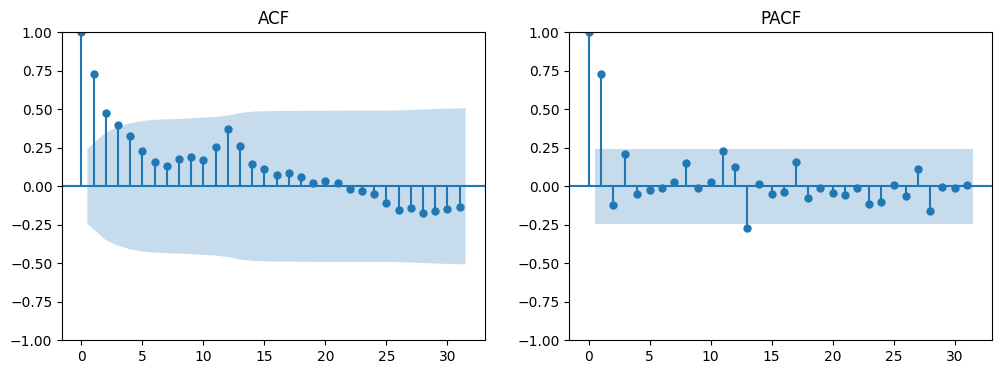


===== TABLETS — National Urban Hypermarkets =====
Observations: 65


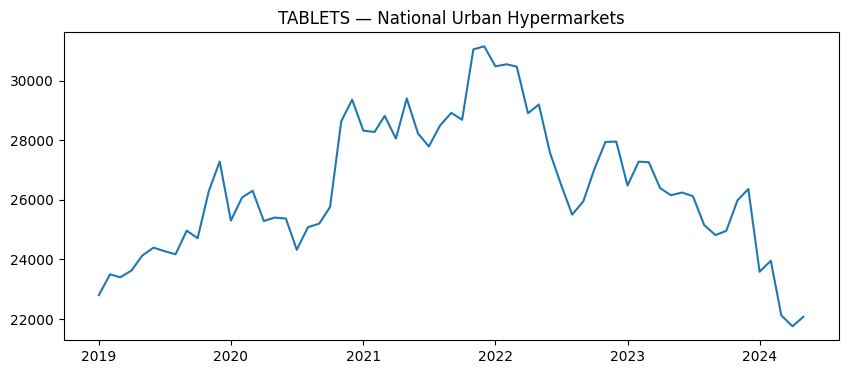

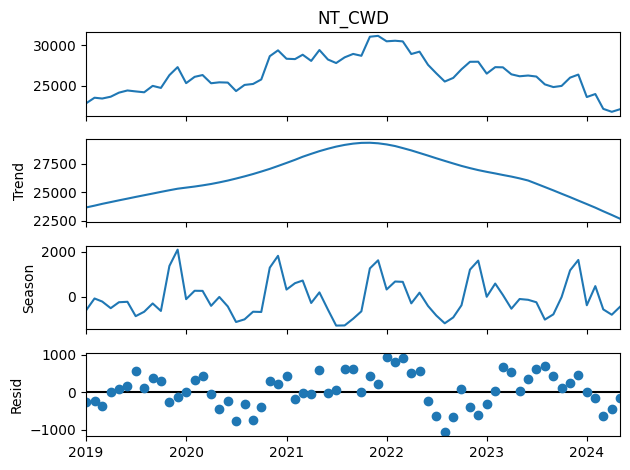

ADF statistic: -1.5962435696938704
p-value: 0.48548019672411474
Ряд нестационарный


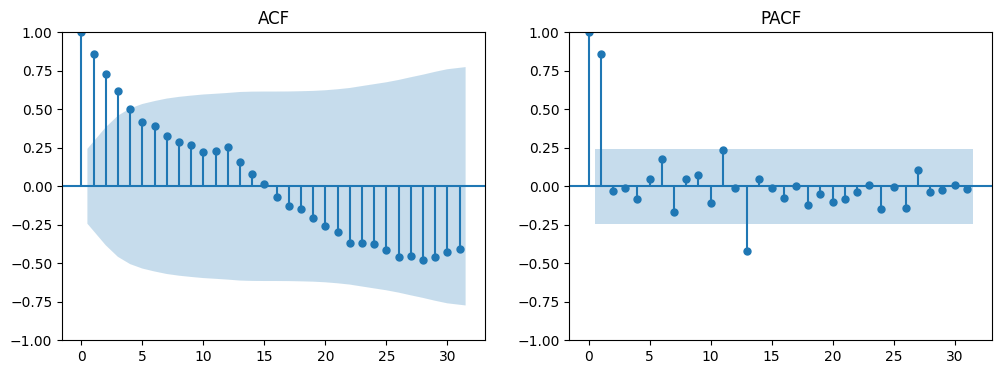


===== TABLETS — National Urban Minimarkets =====
Observations: 65


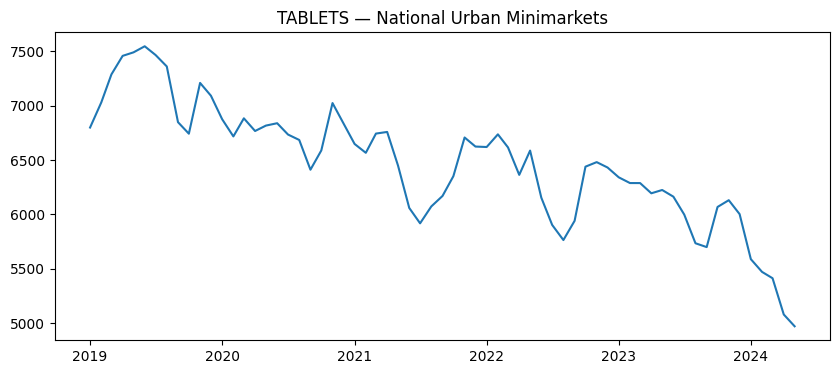

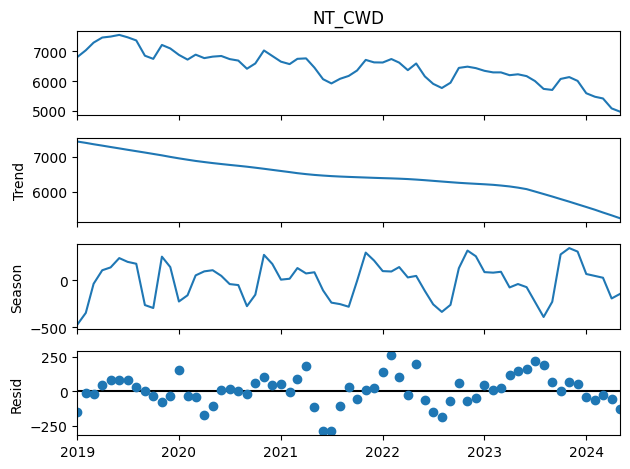

ADF statistic: -0.5468269275077342
p-value: 0.8825501190499843
Ряд нестационарный


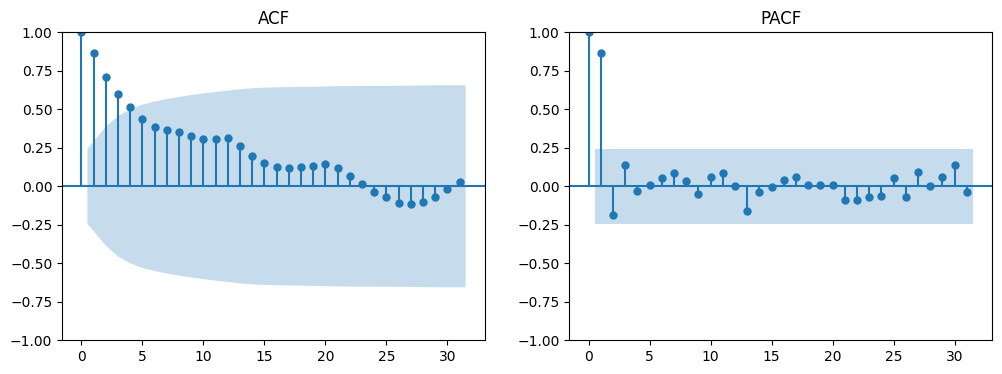


===== TABLETS — National Urban Supermarkets =====
Observations: 65


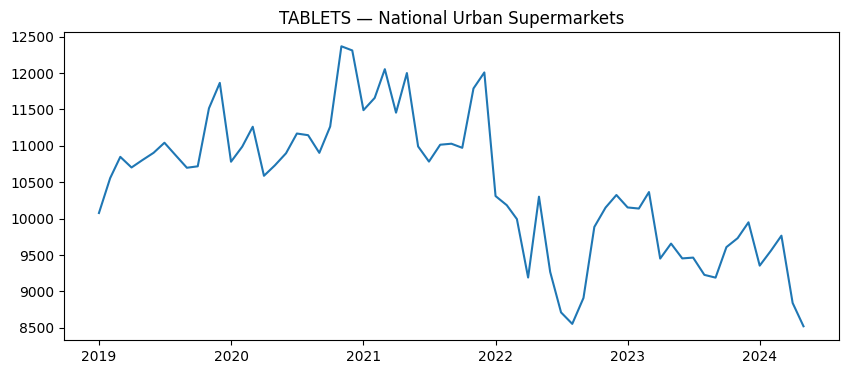

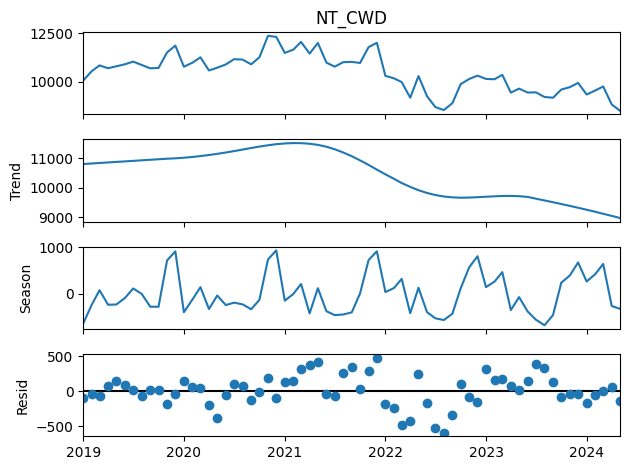

ADF statistic: -1.8277497392779989
p-value: 0.366774324400157
Ряд нестационарный


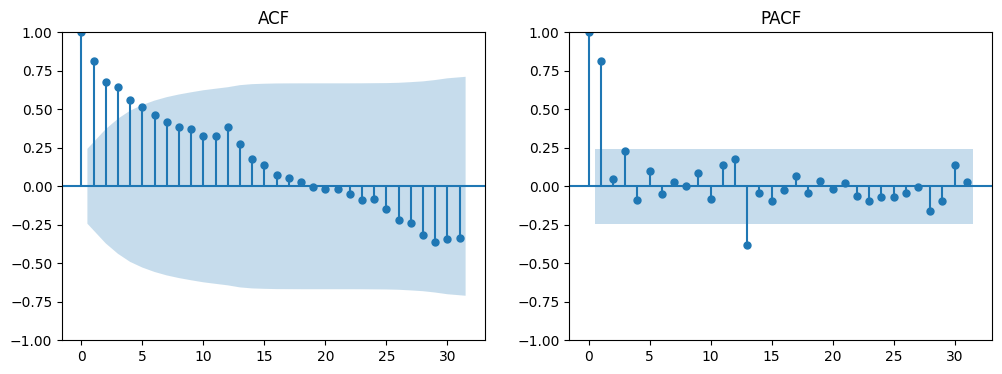


===== TAKE HOME LOOSE KONFETY — Discounters =====
Observations: 65


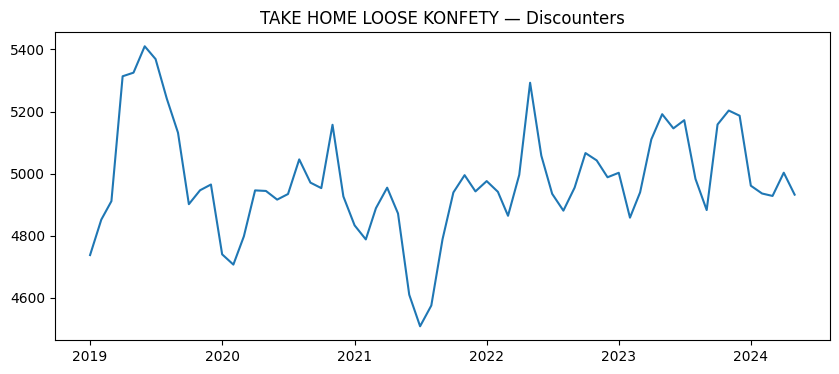

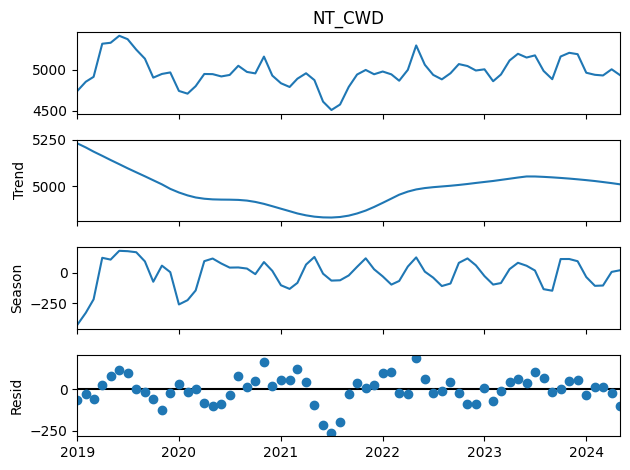

ADF statistic: -4.0264026863693765
p-value: 0.001278397365879346
Ряд стационарный


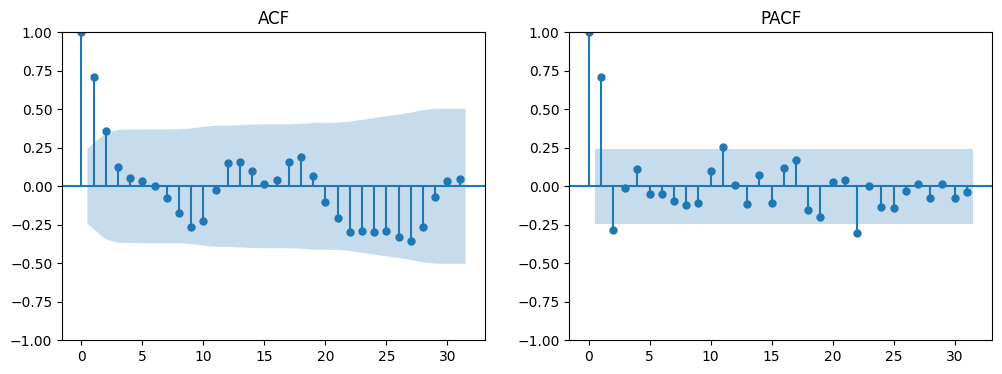


===== TAKE HOME LOOSE KONFETY — National Urban Hypermarkets =====
Observations: 65


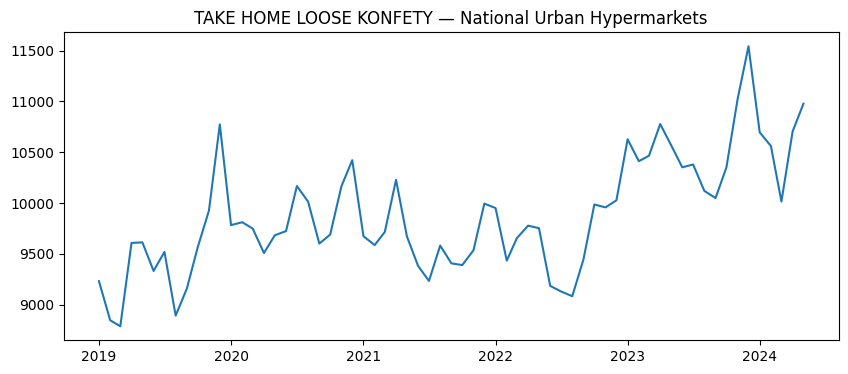

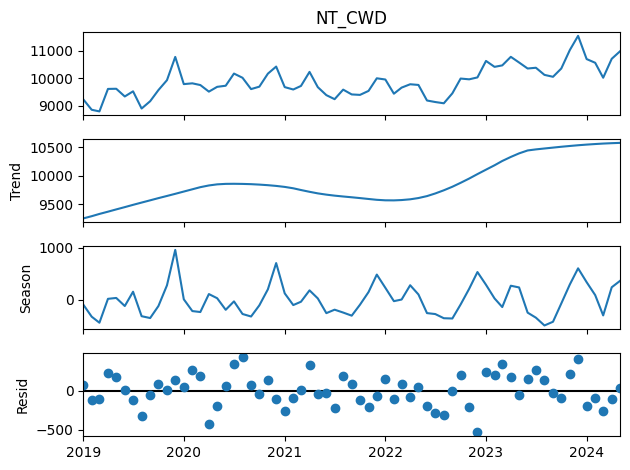

ADF statistic: -1.5361465961585223
p-value: 0.5155604296583927
Ряд нестационарный


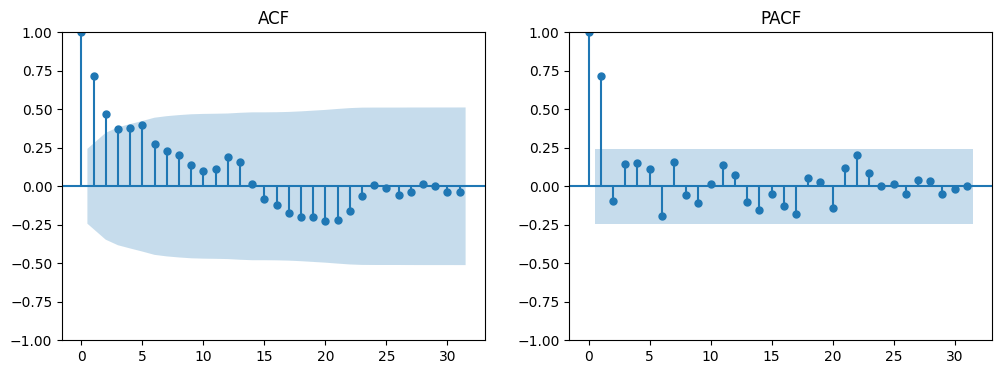


===== TAKE HOME LOOSE KONFETY — National Urban Minimarkets =====
Observations: 65


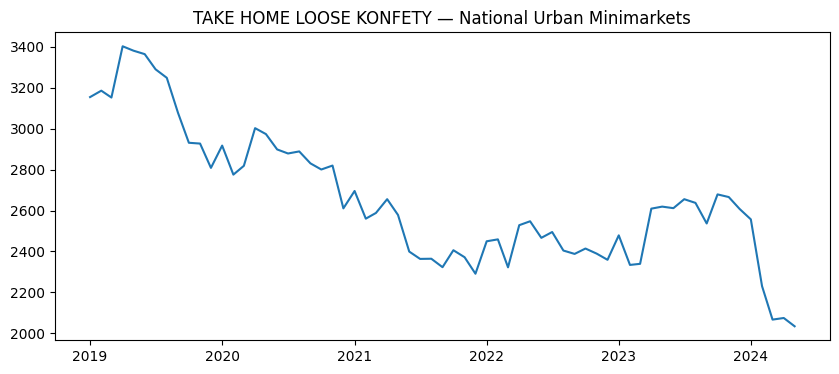

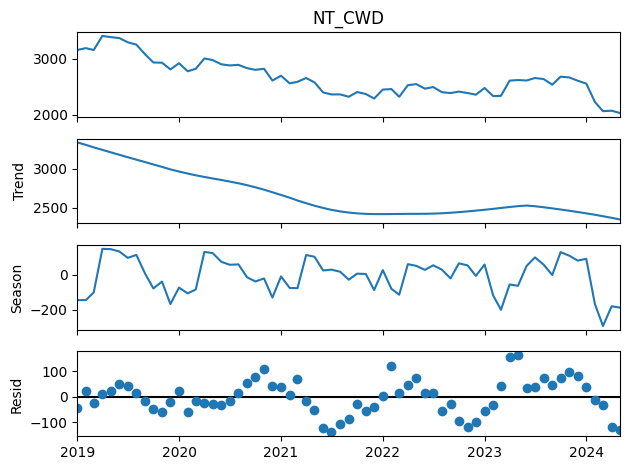

ADF statistic: -1.1551488201045412
p-value: 0.6925860839501929
Ряд нестационарный


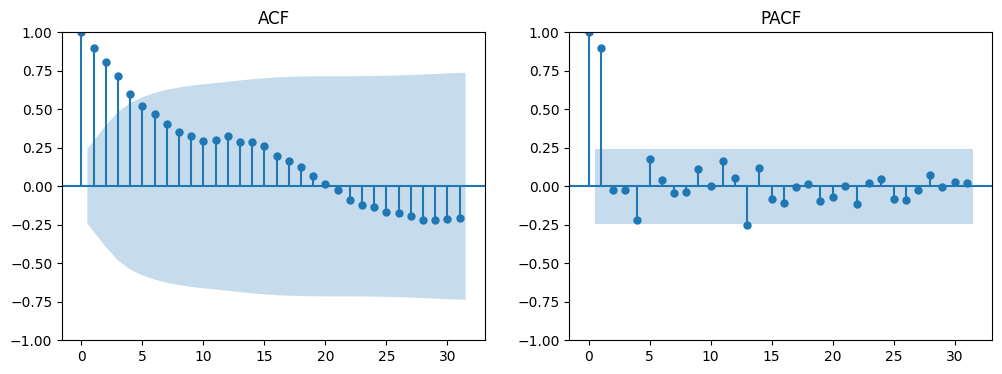


===== TAKE HOME LOOSE KONFETY — National Urban Supermarkets =====
Observations: 65


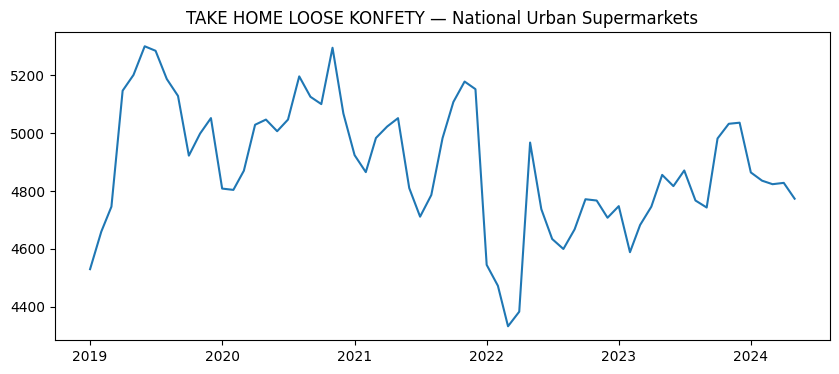

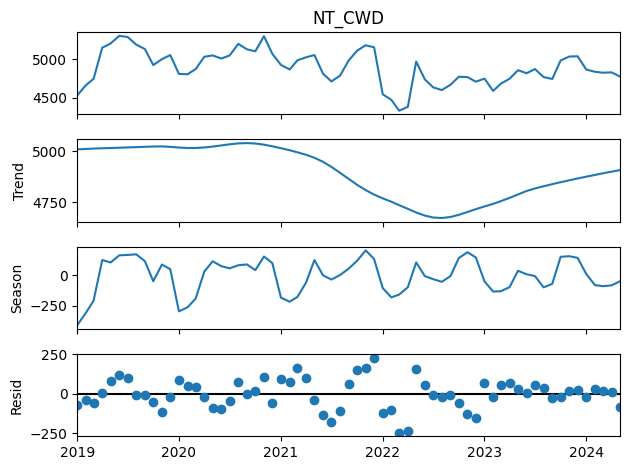

ADF statistic: -3.637034181407081
p-value: 0.00509123125535665
Ряд стационарный


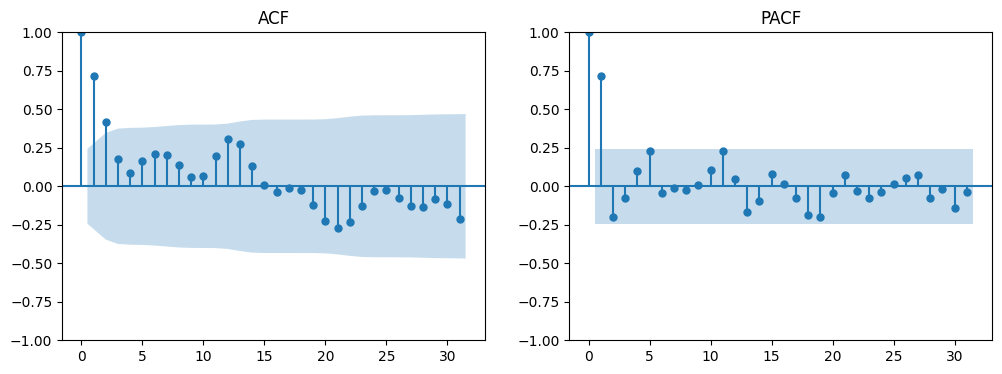

In [9]:
for (product, market), group in ts.groupby(['Row Labels','MKT_SDESC']):

    analyze_series(
        group,
        date_col='PER_SDESC',
        target_col='NT_CWD',
        title=f"{product} — {market}",
        period = 12)

In [180]:
results = []

for (product, market), group in ts.groupby(['Row Labels','MKT_SDESC']):

    series = (
        group
        .sort_values('PER_SDESC')
        .set_index('PER_SDESC')['NT_CWD']
    )

    diag = ts_diagnostics(series)

    results.append({
        "product": product,
        "market": market,
        **diag
    })

ts_summary = pd.DataFrame(results)

In [181]:
ts_summary 

,product,market,mean,std,cv,adf_pvalue,trend_strength,season_strength,acf_lag1,acf_season,pacf_lag1,acf_sum5
0,BAGS,Discounters,2406.410923,445.821080,0.185264,0.565551,0.983426,0.720450,0.941284,0.371882,0.955992,4.086095
1,BAGS,National Urban Hypermarkets,9472.215077,426.234711,0.044998,0.058821,0.543992,0.395425,0.778031,-0.199168,0.790188,2.323189
2,BAGS,National Urban Minimarkets,1594.640923,382.741806,0.240018,0.659540,0.986495,0.708224,0.945638,0.382225,0.960414,4.043263
3,BAGS,National Urban Supermarkets,3179.720308,500.064883,0.157267,0.627372,0.983917,0.656926,0.934186,0.388924,0.948783,4.142861
4,BARS,Discounters,3487.202462,277.933177,0.079701,0.403008,0.889916,0.490979,0.903003,0.005844,0.917112,3.430121
5,BARS,National Urban Hypermarkets,6566.483231,931.471666,0.141852,0.857998,0.959192,0.293581,0.943272,0.423356,0.958010,4.324284
6,BARS,National Urban Minimarkets,3009.864615,170.646434,0.056696,0.542178,0.938097,0.473586,0.887889,0.249099,0.901762,3.720897
7,BARS,National Urban Supermarkets,3534.998923,277.449884,0.078487,0.404941,0.888319,0.564323,0.892796,-0.142436,0.906746,3.333815
8,BITESIZE,Discounters,304.882615,63.213083,0.207336,0.046533,0.601561,0.585618,0.867355,-0.068789,0.880907,2.322584
9,BITESIZE,National Urban Hypermarkets,1452.802000,190.587785,0.131186,0.619770,0.883889,0.478636,0.887924,0.056202,0.901798,3.095765


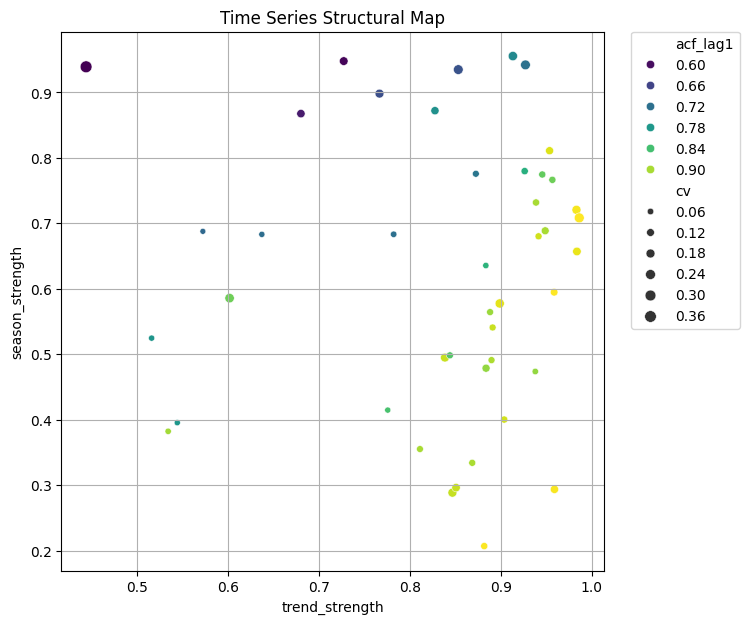

In [194]:
plt.figure(figsize=(7,7))
sns.scatterplot(
    data=ts_summary,
    x="trend_strength",
    y="season_strength",
    size="cv",
    hue="acf_lag1",
    # style="pacf_type",
    palette="viridis",
    # sizes = [50,100]
)

plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
title = 'Time Series Structural Map'
plt.title(title)
plt.savefig('plots/'+title+'.png', bbox_inches="tight")
plt.show()

После проведенного анализа всех временных рядов (продукт+категория магазина) получены следующие результаты:
1) тренд ярко выраженный в большинстве рядов и ряды нестационарные => применить дифференцирование
2) сезонность разнится от умеренной до ярко выраженной
3) сильная зависимость от лаговых признакоы

### Clasterization of ts features

Для выделения основных групп временных рядов было решено применить метод кластеризации к показателям рядов

In [43]:
ts_summary

,product,market,mean,std,cv,adf_pvalue,trend_strength,season_strength,acf_lag1,acf_season,pacf_lag1,acf_sum5,pacf_type
0,BAGS,Discounters,2406.410923,445.821080,0.185264,0.565551,0.983426,0.720450,0.941284,0.371882,0.955992,4.086095,AR
1,BAGS,National Urban Hypermarkets,9472.215077,426.234711,0.044998,0.058821,0.543992,0.395425,0.778031,-0.199168,0.790188,2.323189,AR
2,BAGS,National Urban Minimarkets,1594.640923,382.741806,0.240018,0.659540,0.986495,0.708224,0.945638,0.382225,0.960414,4.043263,AR
3,BAGS,National Urban Supermarkets,3179.720308,500.064883,0.157267,0.627372,0.983917,0.656926,0.934186,0.388924,0.948783,4.142861,AR
4,BARS,Discounters,3487.202462,277.933177,0.079701,0.403008,0.889916,0.490979,0.903003,0.005844,0.917112,3.430121,AR
5,BARS,National Urban Hypermarkets,6566.483231,931.471666,0.141852,0.857998,0.959192,0.293581,0.943272,0.423356,0.958010,4.324284,AR
6,BARS,National Urban Minimarkets,3009.864615,170.646434,0.056696,0.542178,0.938097,0.473586,0.887889,0.249099,0.901762,3.720897,AR
7,BARS,National Urban Supermarkets,3534.998923,277.449884,0.078487,0.404941,0.888319,0.564323,0.892796,-0.142436,0.906746,3.333815,AR
8,BITESIZE,Discounters,304.882615,63.213083,0.207336,0.046533,0.601561,0.585618,0.867355,-0.068789,0.880907,2.322584,AR
9,BITESIZE,National Urban Hypermarkets,1452.802000,190.587785,0.131186,0.619770,0.883889,0.478636,0.887924,0.056202,0.901798,3.095765,AR


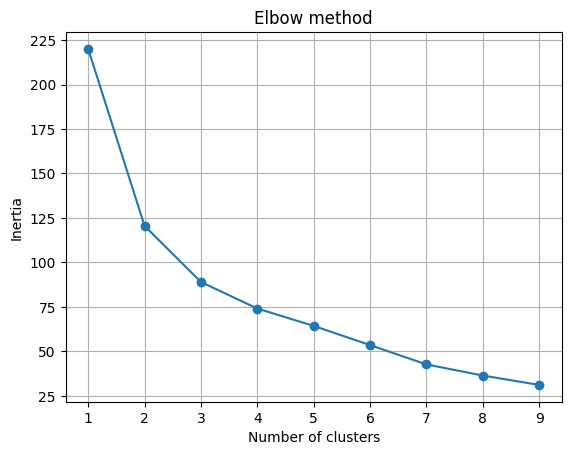

In [201]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = [
    "trend_strength",
    "season_strength",
    "cv",
    "acf_lag1",
    "pacf_lag1"
]
X = scaler.fit_transform(ts_summary[features])

from sklearn.cluster import KMeans

inertia = []

K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
title = "Elbow method"
plt.title(title)
plt.grid()
plt.savefig('plots/'+title+'.png', bbox_inches="tight")
plt.show()

Метод "локтя" показывает, что оптимальное число кластеров = 3

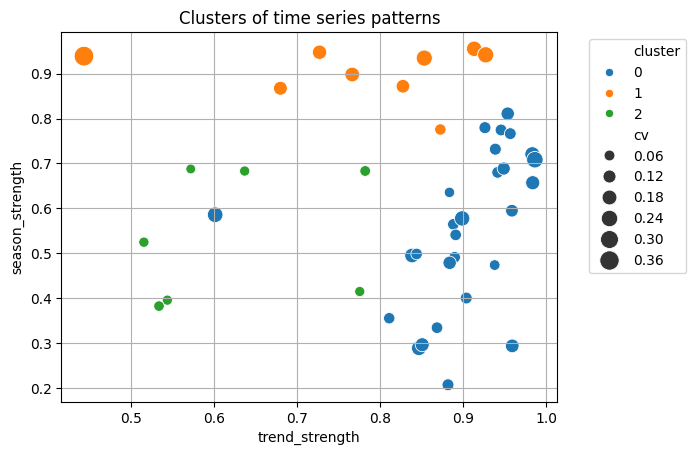

In [202]:
kmeans = KMeans(n_clusters=3, random_state=42)

ts_summary["cluster"] = kmeans.fit_predict(X)

sns.scatterplot(
    data=ts_summary,
    x="trend_strength",
    y="season_strength",
    hue="cluster",
    size="cv",
    palette="tab10",
    sizes=(50,200)
)

title = "Clusters of time series patterns"
plt.title(title)
plt.legend(bbox_to_anchor=(1.05,1))
plt.grid()
plt.savefig('plots/'+title+'.png', bbox_inches="tight")
plt.show()

In [204]:
# cluster's parameters
ts_summary.groupby("cluster")[features].mean()

,trend_strength,season_strength,cv,acf_lag1,pacf_lag1
cluster,,,,,
0,0.900210,0.550938,0.118705,0.902559,0.916662
1,0.779097,0.903458,0.192453,0.681069,0.691711
2,0.622967,0.538657,0.046786,0.776875,0.789014


In [205]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

ts_summary["pc1"] = X_pca[:,0]
ts_summary["pc2"] = X_pca[:,1]
print(pca.explained_variance_ratio_)

[0.58472025 0.24723959]


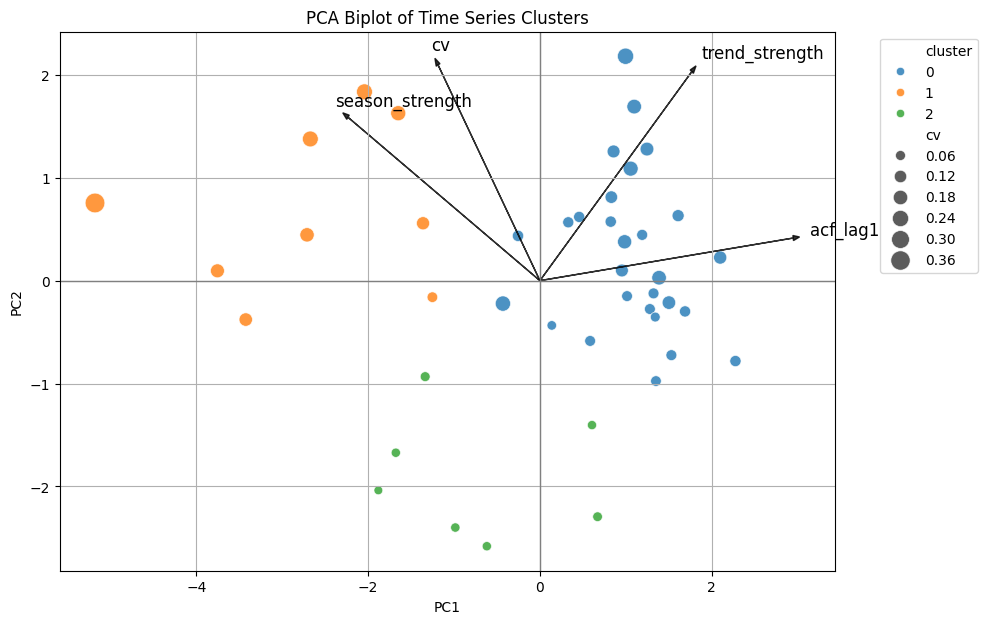

In [206]:
import numpy as np

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

# точки
sns.scatterplot(
    data=ts_summary,
    x="pc1",
    y="pc2",
    hue="cluster",
    size="cv",
    palette="tab10",
    sizes=(40,200),
    alpha=0.8
)

# стрелки признаков
features = ["trend_strength","season_strength","cv","acf_lag1"]

for i, feature in enumerate(features):

    plt.arrow(
        0, 0,
        loadings[i,0]*3,
        loadings[i,1]*3,
        color="black",
        alpha=0.8,
        head_width=0.05
    )

    plt.text(
        loadings[i,0]*3.2,
        loadings[i,1]*3.2,
        feature,
        fontsize=12
    )

plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="grey", linewidth=1)
title = "PCA Biplot of Time Series Clusters"
plt.title(title)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.legend(bbox_to_anchor=(1.05,1))
plt.savefig('plots/'+title+'.png', bbox_inches="tight")
plt.show()

при применении PCA к данным можно видеть, что основные кластеры обладают следующими характеристиками:
1) сильный тренд + умеренная сезонность + сильная зависимость от предыдущего значения $y(t) \sim y(t-1)$ (кластер 0)
2) умеренный тренд + сильная сезонность + сильная зависимость от предыдущего значения $y(t) \sim y(t-1)$ (кластер 1)
3) слабая волатильность (cv) + умеренный тренд + низкая сезонность (кластер 2)

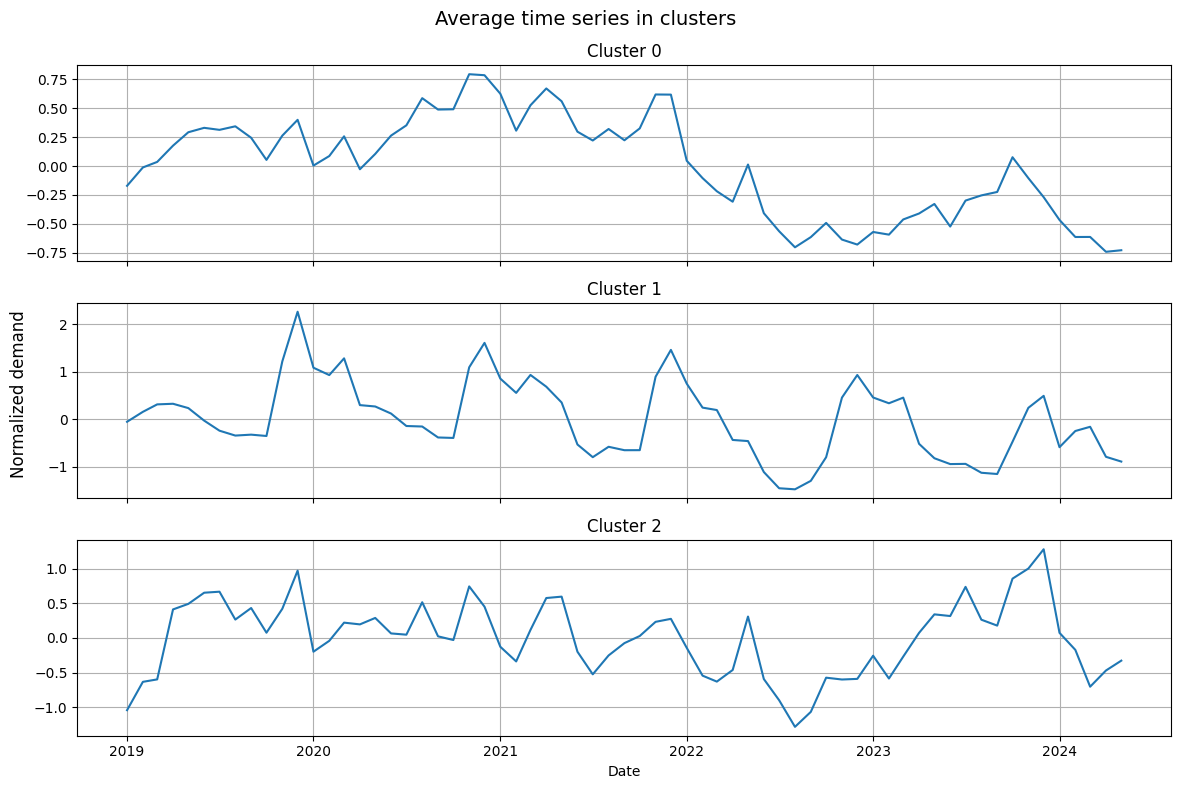

In [207]:
from sklearn.preprocessing import StandardScaler

def normalize_series(x):
    return (x - x.mean()) / x.std()

norm_data = data.copy()
norm_data = norm_data.rename(columns={"Row Labels": "product", "MKT_SDESC":"market"})
norm_data["NT_CWD_norm"] = norm_data.groupby(
    ["product","market"]
)["NT_CWD"].transform(normalize_series)

norm_data = norm_data.merge(
    ts_summary[["product","market","cluster"]],
    on=["product","market"],
    how="left"
)

cluster_ts = (
    norm_data.groupby(["cluster","PER_SDESC"])["NT_CWD_norm"]
    .mean()
    .reset_index()
)


fig, axes = plt.subplots(3, 1, figsize=(12,8), sharex=True)

clusters = sorted(ts_summary["cluster"].unique())

for i, cluster in enumerate(clusters):

    sns.lineplot(
        data=cluster_ts[cluster_ts["cluster"] == cluster],
        x="PER_SDESC",
        y="NT_CWD_norm",
        ax=axes[i]
    )
       
    axes[i].grid(True)
    axes[i].set_title(f"Cluster {cluster}")
    axes[i].set_ylabel("")

axes[-1].set_xlabel("Date")
# общий заголовок
title = "Average time series in clusters"
fig.suptitle(title, fontsize=14)

# общий label оси Y
fig.supylabel("Normalized demand")
plt.tight_layout()
plt.savefig('plots/'+title+'.png', bbox_inches="tight")
plt.show()

Для каждого кластера сделаны усредненные временные ряды, чтобы визуализировать кластеризацию

### Correlation between features

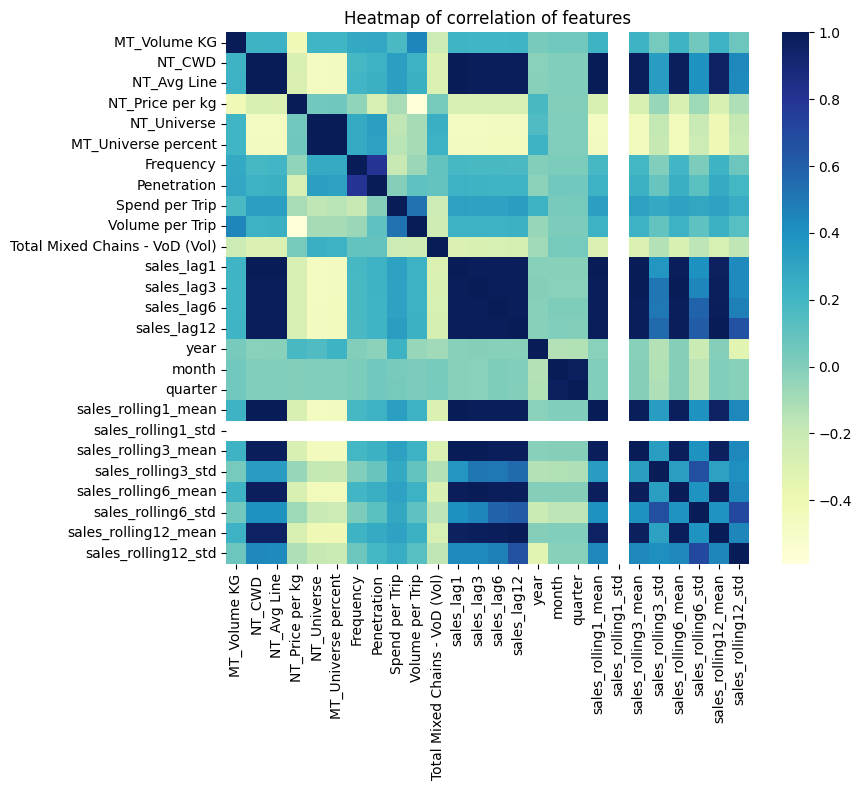

In [216]:
plt.figure(figsize = (9,8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="YlGnBu", )
title = 'Heatmap of correlation of features'
plt.title(title)
plt.tight_layout()
plt.savefig('plots/'+title+'.png')
plt.show()

Целевая переменная `NT_CWD` показывает сильную корреляцию со следующими параметрами:
- лаговые переменные (1 месяц, квартал, полугодие, год) -> продажи очень инерционные
- rolling переменные (mean, std) 3,6,12 месяцев - также показывают высокую корреляцию
- Frequency (поведенчке)
- Penetration
- Spend per Trip
Отсюда можно сделать вывод, что при применении моделей с казуальными переменными мы будем добавлять параметры для увеличения качества метрик

### Differentiation of ts

In [268]:
from statsmodels.tsa.stattools import adfuller

def find_differencing_order(series, max_diff=6):

    series = series.dropna()
    
    for d in range(max_diff + 1):

        if d > 0:
            series = series.diff().dropna()

        pvalue = adfuller(series)[1]

        if pvalue < 0.05:
            return d

    return max_diff

In [269]:
group_cols = ['Row Labels', 'MKT_SDESC']

diff_orders = []

for (product, market), df in data.groupby(group_cols):

    series = df.sort_values("PER_SDESC")["NT_CWD"]

    d = find_differencing_order(series)

    diff_orders.append({
        "Row Labels": product,
        "MKT_SDESC": market,
        "differentiation": d
    })

diff_df = pd.DataFrame(diff_orders)

In [274]:
ts_summary = ts_summary.merge(
    diff_df,
    right_on=['Row Labels', 'MKT_SDESC'],
    left_on=['product', 'market'],
    how='left'
)
ts_summary = ts_summary.drop(columns=['Row Labels', 'MKT_SDESC'])

In [278]:
ts_summary.head(10)

,product,market,mean,std,cv,adf_pvalue,trend_strength,season_strength,acf_lag1,acf_season,pacf_lag1,acf_sum5,cluster,pc1,pc2,differentiation
0,BAGS,Discounters,2406.410923,445.821080,0.185264,0.565551,0.983426,0.720450,0.941284,0.371882,0.955992,4.086095,0,1.097831,1.691701,1
1,BAGS,National Urban Hypermarkets,9472.215077,426.234711,0.044998,0.058821,0.543992,0.395425,0.778031,-0.199168,0.790188,2.323189,2,-0.618098,-2.581229,1
2,BAGS,National Urban Minimarkets,1594.640923,382.741806,0.240018,0.659540,0.986495,0.708224,0.945638,0.382225,0.960414,4.043263,0,0.997116,2.181279,1
3,BAGS,National Urban Supermarkets,3179.720308,500.064883,0.157267,0.627372,0.983917,0.656926,0.934186,0.388924,0.948783,4.142861,0,1.246679,1.278927,1
4,BARS,Discounters,3487.202462,277.933177,0.079701,0.403008,0.889916,0.490979,0.903003,0.005844,0.917112,3.430121,0,1.280607,-0.275981,1
5,BARS,National Urban Hypermarkets,6566.483231,931.471666,0.141852,0.857998,0.959192,0.293581,0.943272,0.423356,0.958010,4.324284,0,2.099089,0.224724,1
6,BARS,National Urban Minimarkets,3009.864615,170.646434,0.056696,0.542178,0.938097,0.473586,0.887889,0.249099,0.901762,3.720897,0,1.343089,-0.353798,1
7,BARS,National Urban Supermarkets,3534.998923,277.449884,0.078487,0.404941,0.888319,0.564323,0.892796,-0.142436,0.906746,3.333815,0,1.014642,-0.150267,1
8,BITESIZE,Discounters,304.882615,63.213083,0.207336,0.046533,0.601561,0.585618,0.867355,-0.068789,0.880907,2.322584,0,-0.430965,-0.222865,0
9,BITESIZE,National Urban Hypermarkets,1452.802000,190.587785,0.131186,0.619770,0.883889,0.478636,0.887924,0.056202,0.901798,3.095765,0,0.954689,0.098752,1


In [279]:
def apply_differencing(series, d):
    for _ in range(d):
        series = series.diff()
    return series

In [280]:
data = data.merge(
    diff_df,
    on=['Row Labels', 'MKT_SDESC'],
    how='left'
)

data["NT_CWD_diff"] = (
    data
    .groupby(['Row Labels','MKT_SDESC'])
    .apply(lambda x: apply_differencing(x["NT_CWD"], x["differentiation"].iloc[0]))
    .reset_index(level=[0,1], drop=True)
)

In [282]:
data.to_csv('data/data_4_forecast.csv')
ts_summary.to_csv('data/ts_meta.csv')

# Results

Проведен EDA:
- Получены графики продаж внутри категорий product, market, (product,market)
- Проведены декомпозиция рядов, adf, acf, pacf
- Получены порядки диффиренцирования
- Кластеризация для определения основных групп временных рядов
- Изучены корреляции с целевой переменной
- Введены дополнительные переменные
- - лаги: 1,3,6,12 месяцев
  - rolling statistics mean, std
  - 

|   cluster |   trend_strength |   season_strength |        cv |   acf_lag1 | forecast model|
|----------:|-----------------:|------------------:|----------:|-----------:|-----------:|
|         0 |         0.90021  |          0.550938 | 0.118705  |   0.902559 |
|         1 |         0.779097 |          0.903458 | 0.192453  |   0.681069 |
|         2 |         0.622967 |          0.538657 | 0.0467858 |   0.776875 |